# Capítulo 5: 5 ModelValidationAndSelection

Este cuaderno unificado contiene todos los ejemplos y ejercicios del capítulo.
Puede ejecutarse de forma independiente en Google Colab.

**Nota:** Este cuaderno incluye automáticamente todas las funciones compartidas necesarias.

## Funciones Compartidas

Esta sección contiene todas las funciones compartidas necesarias para ejecutar los ejemplos.
Puedes colapsar esta sección haciendo clic en el encabezado.

**Nota:** Estas funciones se cargan automáticamente al inicio del cuaderno.

(shared_functions)=
# Funciones compartidas

Este cuaderno contiene funciones que se reutilizan comúnmente en el libro, para cargar y guardar datos, ajustar y evaluar modelos de predicción, o graficar resultados. 

El cuaderno se puede descargar de GitHub con

```
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.ipynb

```

El cuaderno se puede incluir en otros cuadernos usando

```
%run shared_functions
```



##  General imports

In [ ]:
# General
import os
import pandas as pd
import numpy as np
import math
import sys
import time
import pickle
import json
import datetime
import random

#import sklearn
import sklearn
from sklearn import *

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

import graphviz
import xgboost

# For imbalanced learning
import imblearn

import warnings
warnings.filterwarnings('ignore')



## Loading and saving data

### read_from_files

Primer uso en [Capítulo 3, Transformación de Características Baseline](Baseline_Feature_Transformation).

In [ ]:
# Load a set of pickle files, put them together in a single DataFrame, and order them by time
# It takes as input the folder DIR_INPUT where the files are stored, and the BEGIN_DATE and END_DATE
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Note: -1 are missing values for real world data 
    df_final=df_final.replace([-1],0)
    
    return df_final


### save_object


In [ ]:
#Save oject as pickle file
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)


## Data preprocessing

### scaleData

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])
    
    return (train,test)

## Train/Test splitting strategies

### get_train_test_set

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Ratio de muestreo agregado en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7,
                       sampling_ratio=1.0,
                       random_state=0):
    
    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Get the test set data
    test_df = []
    
    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)
                               


In [ ]:
def get_train_delay_test_set(transactions_df,
                             start_date_training,
                             delta_train=7,delta_delay=7,delta_test=7,
                             sampling_ratio=1.0,
                             random_state=0):
    
    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Get the delay set data
    delay_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training+datetime.timedelta(days=delta_train)) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train)+
                                                                               +datetime.timedelta(days=delta_delay))]
    
    # Get the test set data
    test_df = []
    
    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, delay_df, test_df)

### prequentialSplit

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
    # Para cada fold
    for fold in range(n_folds):
        
        # Desplazar hacia atrás la fecha de inicio para entrenamiento por el índice del fold veces el período de evaluación (delta_assessment)
        # (Ver Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Obtener los conjuntos de entrenamiento y prueba (evaluación)
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
    
        # Obtener los índices de los dos conjuntos, y agregarlos a la lista de divisiones prequenciales
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices


## Predictions functions

### fit_model_and_get_predictions

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Por defecto, escala los datos de entrada
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # Primero entrenamos el clasificador usando el método `fit`, y pasamos como argumentos las características de entrada y salida
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # Luego obtenemos las predicciones en los datos de entrenamiento y prueba usando el método `predict_proba`
    # Las predicciones se devuelven como un array de numpy, que proporciona la probabilidad de fraude para cada transacción 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # El resultado se devuelve como un diccionario que contiene los modelos ajustados, 
    # y las predicciones en los conjuntos de entrenamiento y prueba
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

## Performance assessment

### card_precision_top_k_day

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k_day(df_day,top_k):
    
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k



### card_precision_top_k

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordenar días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # Para cada día, calcular precisión top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Calcular la media
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Devuelve precisión top k por día como una lista, y la media resultante
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k



### card_precision_top_k_custom

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Creemos un DataFrame predictions_df, que contiene todas las transacciones que coinciden con los índices del fold actual
    # (índices del vector y_true)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Calcular el CP@k usando la función implementada en el Capítulo 4, Sección 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Devolver el mean_card_precision_top_k
    return mean_card_precision_top_k


### performance_assessment

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances


### performance_assessment_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

### execution_times_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

### get_class_from_fraud_probability

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
# Getting classes from a vector of fraud probabilities and a threshold
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes


### threshold_based_metrics

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [ ]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 1 # 1 if TP+FP=0
        FDR = 1 # 1 if TP+FP=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 1 # 1 if TN+FN=0
        FOR = 1 # 1 if TN+FN=0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df

### get_summary_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    performances_df.reset_index(drop=True,inplace=True)

    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    for metric in metrics:
    
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    optimal_test_performance = []
    optimal_parameters = []

    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    performances_results.loc["Optimal parameter(s)"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results

### model_selection_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC'):
    
    # Nota: max_depth de 50 es similar a None
    default_parameters_dictionary={
        "Decision Tree": 50,
        "Logstic Regression": 1,
        "Random Forest": "100/50",
        "XGBoost": "100/0.1/2"
    }
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class, performances_df in performances_df_dictionary.items():
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Devolver los rendimientos medios y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.1/3"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Devolver los rendimientos medios y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

## Model selection

### prequential_grid_search

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df



### model_selection_wrapper

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


### kfold_cv_with_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_=sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                       scoring=['roc_auc',
                                                                'average_precision',
                                                                'balanced_accuracy'],
                                                       return_estimator=True)
    
    results=round(pd.DataFrame(cv_results_),3)
    results_mean=list(results.mean().values)
    results_std=list(results.std().values)
    results_df=pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                              str(round(results_std[i],3)) for i in range(len(results))]],
                            columns=['Fit time (s)','Score time (s)',
                                     'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0=cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df=pd.DataFrame({'X1':X[train_index,0],'X2':X[train_index,1], 'Y':y[train_index]})
    test_df=pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

## Plotting

### get_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_compromised_card_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_card_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats



### get_template_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [ ]:
# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train+delta_delay), 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


### get_template_roc_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_roc_curve(ax, title,fs,random=True):
    
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)
    
    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")



### get_template_pr_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [ ]:
def get_template_pr_curve(ax, title,fs, baseline=0.5):
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
    ax.set_ylabel('Precision', fontsize=fs)
    
    ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))


### get_performance_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plot for a single performance metric
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list es la lista de tipos de experimentos, típicamente contiene 'Test', 'Train', o 'Valid'
    # Para todos los tipos de experimentos
    for i in range(len(expe_type_list)):
    
        # Columna en performances_df para la cual recuperar los datos 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Plot data on graph
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # If performances_df contains confidence intervals, add them to the graph
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # If summary_performances table is present, adds vertical dashed bar for best estimated parameter 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Set title, and x and y axes labels
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)
    

### get_performances_plots

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plots for a set of performance metric
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### get_execution_times_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Get the performance plot for a single performance metric
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Plot data on graph
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Set title, and x and y axes labels
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
# Get the performance plot for a single performance metric
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # width of the bars
    barWidth = 0.3
    # The x position of bars
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Create Default parameters bars (Orange)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Create Best validation parameters bars (Red)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Create Optimal parameters bars (Green)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Set title, and x and y axes labels
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### plot_decision_boundary_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Plot the training points
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)

### plot_decision_boundary

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [ ]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n With training data",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Decision surface of the decision tree\n With test data",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
              #labels=[0,1], 
              bbox_to_anchor=(1.05, 1),
              title="Class")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

## Deep Learning functions



In [ ]:
import torch
import torch.nn.functional as F

### seed_everything

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

### Utilidades para gestión de datos, entrenamiento y evaluación

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = x
        self.y = y

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index]

def prepare_generators(training_set,valid_set,batch_size=64):
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss

class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("New best score:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iterations since best score.")
                
        return self.counter <= self.patience  
    
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    #Setting the model in training mode
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    #Training loop
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            # Forward pass
            y_pred = model(x_batch)
            # Compute Loss
            loss = criterion(y_pred.squeeze(), y_batch)
            # Backward pass
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        #showing last training loss after each epoch
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Epoch {}: train loss: {}'.format(epoch, np.mean(train_loss)))
        #evaluating the model on the test set after each epoch    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('valid loss: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Early stopping")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

def per_sample_mse(model,generator):
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().numpy())
        batch_losses.extend(loss_app)
    return batch_losses

class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1  
        
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)

### FraudDatasetUnsupervised

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [ ]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Initialization'
        self.x = x
        self.output = output

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.output:
            return self.x[index], self.x[index]
        else:
            return self.x[index]

### Módulos SimpleFraudMLPWithDropout y FraudMLP

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [ ]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output
        
class FraudMLP(torch.nn.Module):
    
        def __init__(self, input_size,hidden_size=100,num_layers=1,p=0):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

### Módulo SimpleAutoencoder

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [ ]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parameters
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            #encoder
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            #decoder 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            #linear activation in final layer)            
            
            return output

### Módulo de Atención

Primer uso en [Capítulo 7, Modelos secuenciales y aprendizaje de representación](SequentialModeling).

In [ ]:
# source : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

class Attention(torch.nn.Module):
    r"""
    Applies an attention mechanism on the output features from the decoder.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): The number of expected features in the output
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor containing the output features from the decoder.
        - **context** (batch, input_len, dimensions): tensor containing features of the encoded input sequence.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor containing the attended output features from the decoder.
        - **attn** (batch, output_len, input_len): tensor containing attention weights.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn


---

**Fin de Funciones Compartidas**


---

## ValidationStrategies


(Validation_Strategies)=
# Estrategias de validación


El propósito de un sistema de detección de fraude es maximizar la detección de transacciones fraudulentas que ocurrirán en el *futuro*. 

El enfoque más directo para entrenar y evaluar un modelo de predicción para un sistema de detección de fraude se ilustra en la Fig. 1. Para claridad de la ilustración, el flujo de datos de transacciones se discretiza en bloques. Un bloque corresponde a un período de tiempo (como una semana o un día). Asumimos que el modelo de predicción debe actualizarse cada nuevo bloque {cite}`dal2017credit,dal2015adaptive`. 

Este es el enfoque que usamos en la sección {ref}`Baseline_FDS`. Los bloques correspondían a una semana de datos de transacciones. Un bloque de datos se usó para entrenamiento, y un bloque de datos para prueba. También se usó un retraso de una semana para separar los bloques de entrenamiento y prueba.

Más generalmente, dado un conjunto de bloques de transacciones pasadas recopiladas hasta el tiempo actual $t$, el propósito del modelo de predicción es proporcionar predicciones para transacciones que ocurrirán en el siguiente bloque (transacciones *futuras*, también llamadas transacciones de *prueba*, en amarillo) {cite}`dal2017credit,dal2015adaptive`. El conjunto de bloques que se usan para entrenamiento son los *bloques de entrenamiento* (en azul oscuro). Debido al retraso en obtener las etiquetas de transacciones (Ver la sección {ref}`Fraud_Detection_System`), las transacciones más recientes generalmente no pueden usarse para entrenamiento (período de retraso, en azul claro) y se eliminan. Los bloques más antiguos también generalmente se descartan, debido a la deriva de concepto (en azul claro, también eliminados). Denotemos las longitudes de los períodos de entrenamiento, retraso y prueba por $\delta_{train}$, $\delta_{delay}$, y $\delta_{test}$, respectivamente.

![alt text](images/stream_train.png)
<div align="center">Fig. 1. El propósito de un modelo de predicción para detección de fraude es proporcionar predicciones para transacciones que ocurren en el futuro (en amarillo). El modelo se entrena en un conjunto de transacciones pasadas (en azul oscuro).</div>

El rendimiento de un modelo en datos de entrenamiento a menudo es un mal indicador del rendimiento en datos futuros {cite}`bontempi2021statistical,bishop2006pattern,friedman2001elements`. El primero se conoce como *rendimiento de entrenamiento*, y el segundo como *rendimiento de prueba* (es decir, el rendimiento del modelo cuando se *prueba* en datos no vistos). En particular, aumentar el grado de libertad de un modelo (como la profundidad para un árbol de decisión) siempre permite aumentar el rendimiento de entrenamiento, pero generalmente conduce a rendimientos de prueba más bajos (fenómeno de *sobreajuste*). 

Los procedimientos de validación tienen como objetivo resolver este problema estimando, en datos pasados, el rendimiento de prueba de un modelo de predicción apartando una parte de ellos {cite}`cerqueira2020evaluating,gama2014survey`. Funcionan dividiendo los datos etiquetados pasados en dos conjuntos, el *conjunto de entrenamiento* y el *conjunto de validación*, que simulan la configuración de un sistema de detección de fraude del mundo real. El conjunto de validación desempeña el papel del conjunto de prueba. Esto se ilustra en la Fig. 2. 

![alt text](images/stream_valid.png)
<div align="center">Fig. 2. Un procedimiento de validación simula en datos pasados el procedimiento de entrenamiento que se usará para proporcionar predicciones en datos de prueba (no vistos). Usa el conjunto de validación para estimar el rendimiento de la etapa de prueba. </div>

Para simular mejor la configuración ilustrada en la Fig. 1, los conjuntos de entrenamiento y validación se separan con el mismo período de retraso. La longitud del conjunto de validación ($\delta_{valid}$) se establece igual a la longitud del conjunto de prueba ($\delta_{test}$). El rendimiento de un modelo en el conjunto de validación se usa como una estimación del rendimiento que se espera en el conjunto de prueba. 

La estrategia de validación ilustrada en la Fig. 2 se llama *validación hold-out* (ya que parte de las transacciones etiquetadas disponibles se mantiene fuera de los datos de entrenamiento). Variantes de este enfoque son la *validación hold-out repetida* y la *validación prequencial*. La primera es la misma que la validación *hold-out* excepto que el procedimiento se repite varias veces usando diferentes subconjuntos de los datos de entrenamiento. La segunda es una variante que repite la validación hold-out desplazando los conjuntos de entrenamiento y validación en el pasado. Tanto las validaciones hold-out repetidas como las prequenciales permiten proporcionar estimaciones de rendimientos en el conjunto de prueba, junto con intervalos de confianza {cite}`cerqueira2020evaluating,gama2014survey`.

Las siguientes secciones detallan estos procedimientos de validación. Primero ilustramos usando datos simulados y árboles de decisión que el rendimiento de entrenamiento es una mala estimación del rendimiento de prueba. Luego proporcionamos implementaciones de las validaciones hold-out, hold-out repetida y prequencial, y discutimos sus pros y contras. 


In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 41751  100 41751    0     0   147k      0 --:--:-- --:--:-- --:--:--  147k


(Training_Vs_Test_Performances)=
## Rendimiento de entrenamiento versus rendimiento de prueba

Primero ilustramos que el rendimiento de entrenamiento es un mal indicador del rendimiento de prueba. Reutilizamos la misma configuración experimental que en el Capítulo 3 - {ref}`Baseline_FDS`. Se usa una semana de datos para entrenar el modelo de predicción, y una semana de datos para probar las predicciones. Nos basamos en un modelo de árbol de decisión, y evaluamos los rendimientos de entrenamiento y prueba para árboles de decisión con diferentes profundidades de árbol, que van de dos a cincuenta. Los rendimientos se evalúan en términos de AUC ROC, Precisión Promedio, y Precisión de Tarjetas@100 como se motivó en el Capítulo 4 - {ref}`Performance_Metrics`.

Carguemos primero los datos simulados, y establezcamos la característica de salida y las características de entrada como en la sección {ref}`Baseline_FDS_Decision_Tree`.

In [2]:
# Note: We load more data than three weeks, as the experiments in the next sections
# will require up to three months of data

# Load data from the 2018-06-11 to the 2018-09-14

DIR_INPUT='simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


Load  files
CPU times: user 1.04 s, sys: 778 ms, total: 1.82 s
Wall time: 2.16 s
919767 transactions loaded, containing 8195 fraudulent transactions


Usar una semana para entrenamiento, una semana para prueba, y una semana de retraso corresponde a la configuración experimental que se ilustra en la Fig. 3. 

![alt text](images/stream_train_1block.png)
<div align="center">Fig. 3. Configuración experimental donde se usa una semana de datos para entrenamiento y una semana de datos para prueba, separadas por un retraso de una semana. Cada bloque corresponde a una semana de datos.</div>

Establezcamos el inicio del período de entrenamiento al 2018-07-25, y los deltas para entrenamiento, retraso y prueba a 7 días (una semana). 

In [3]:
# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=7
delta_delay=7
delta_test=7


Definimos una función `get_performances_train_test_sets` para entrenar un modelo, y evaluar sus rendimientos en los conjuntos de entrenamiento y prueba. La función realiza los mismos pasos que los descritos en la sección {ref}`Baseline_FDS`. Los cuatro pasos principales son:

* Establecer la fecha de inicio para el período de entrenamiento, y los deltas para entrenamiento, retraso y prueba
* Obtener los conjuntos de entrenamiento y prueba
* Ajustar el modelo y recopilar las predicciones
* Evaluar los rendimientos para ambos conjuntos de entrenamiento y prueba



In [4]:
def get_performances_train_test_sets(transactions_df, classifier,
                                     input_features, output_feature,
                                     start_date_training, 
                                     delta_train=7, delta_delay=7, delta_test=7,
                                     top_k_list=[100],
                                     type_test="Test", parameter_summary=""):

    # Get the training and test sets
    (train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                           delta_train=delta_train,
                                           delta_delay=delta_delay,
                                           delta_test=delta_test)
    
    # Fit model
    start_time=time.time() 
    model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                     input_features, output_feature)
    execution_time=time.time()-start_time
    
    # Compute fraud detection performances
    test_df['predictions']=model_and_predictions_dictionary['predictions_test']
    performances_df_test=performance_assessment(test_df, top_k_list=top_k_list)
    performances_df_test.columns=performances_df_test.columns.values+' '+type_test
    
    train_df['predictions']=model_and_predictions_dictionary['predictions_train']
    performances_df_train=performance_assessment(train_df, top_k_list=top_k_list)
    performances_df_train.columns=performances_df_train.columns.values+' Train'
    
    performances_df=pd.concat([performances_df_test,performances_df_train],axis=1)
    
    performances_df['Execution time']=execution_time
    performances_df['Parameters summary']=parameter_summary
    
    return performances_df


Calculemos por ejemplo las precisiones de prueba y entrenamiento usando un árbol de decisión con profundidad 2. 

In [7]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth=2, random_state=0)

performances_df=get_performances_train_test_sets(transactions_df, classifier, 
                                                 input_features, output_feature,
                                                 start_date_training=start_date_training, 
                                                 delta_train=delta_train, 
                                                 delta_delay=delta_delay, 
                                                 delta_test=delta_test,
                                                 parameter_summary=2
                                                )

In [8]:
performances_df

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.763,0.496,0.241,0.802,0.586,0.394,0.451595,2


Tenga en cuenta que los rendimientos son los mismos que los obtenidos en la sección {ref}`Baseline_FDS_Performances_Simulation`.

Podemos entonces calcular los rendimientos para diferentes profundidades de árbol de decisión. Variemos las profundidades del árbol de decisión de dos a cincuenta, usando los siguientes valores: $[2,3,4,5,6,7,8,9,10,20,50]$.

In [9]:
list_params = [2,3,4,5,6,7,8,9,10,20,50]

performances_df=pd.DataFrame()

for max_depth in list_params:
    
    classifier = sklearn.tree.DecisionTreeClassifier(max_depth = max_depth, random_state=0)

    performances_df=performances_df.append(
        get_performances_train_test_sets(transactions_df, classifier, 
                                         input_features, output_feature, 
                                         start_date_training=start_date_training, 
                                         delta_train=delta_train, 
                                         delta_delay=delta_delay, 
                                         delta_test=delta_test,            
                                         parameter_summary=max_depth
                           )
    )
    
performances_df.reset_index(inplace=True,drop=True)

In [10]:
performances_df

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.763,0.496,0.241,0.802,0.586,0.394,0.468689,2
1,0.795,0.562,0.267,0.815,0.615,0.409,0.582330,3
2,0.802,0.570,0.269,0.829,0.635,0.411,0.550253,4
3,0.814,0.581,0.280,0.835,0.649,0.419,0.580715,5
4,0.817,0.588,0.280,0.842,0.662,0.421,0.642127,6
5,0.793,0.542,0.254,0.876,0.679,0.427,0.666566,7
6,0.786,0.546,0.257,0.884,0.717,0.436,0.727614,8
7,0.756,0.499,0.246,0.896,0.737,0.437,0.773424,9
8,0.750,0.484,0.244,0.901,0.756,0.440,0.782423,10
9,0.739,0.392,0.243,0.974,0.907,0.506,1.194687,20


For better visualization of the results, let us plot the resulting performances in terms of AUC ROC, AP, and CP@100, as a function of the decision tree depth. 

In [ ]:
# Get the performance plot for a single performance metric
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list es la lista de tipos de experimentos, típicamente contiene 'Test', 'Train', o 'Valid'
    # Para todos los tipos de experimentos
    for i in range(len(expe_type_list)):
    
        # Columna en performances_df para la cual recuperar los datos 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Graficar datos en el gráfico
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # Si performances_df contiene intervalos de confianza, agregarlos al gráfico
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # Si la tabla summary_performances está presente, agrega barra vertical punteada para el mejor parámetro estimado 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters ($k^*$)']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Set title, and x and y axes labels
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)

# Get the performance plots for a set of performance metric
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

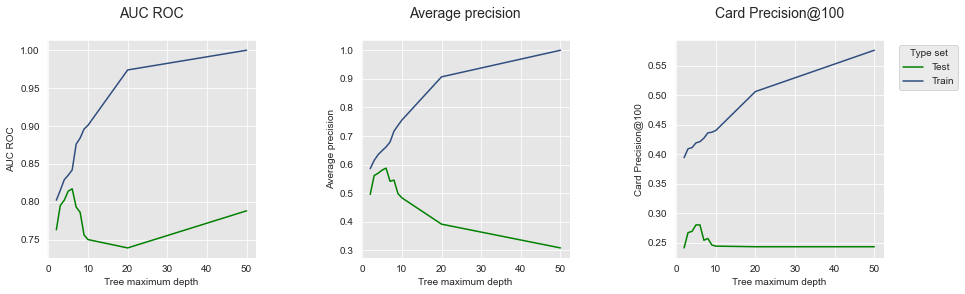

In [12]:
get_performances_plots(performances_df, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Train'],expe_type_color_list=['#008000','#2F4D7E'])

El rendimiento de entrenamiento se grafica en azul, y el rendimiento de prueba en verde. El gráfico ilustra claramente el fenómeno de *sobreajuste*: El rendimiento de entrenamiento sigue aumentando con la profundidad del árbol y alcanza un ajuste perfecto, es decir, el AUC ROC/AP más alto posible, para una profundidad de cincuenta. El rendimiento de prueba sin embargo alcanza su punto máximo en una profundidad de 6. Una profundidad de 6 es por lo tanto la profundidad que maximiza el rendimiento en el conjunto de prueba cuando se usa un árbol de decisión como modelo de predicción. 

Recordemos también que la Precisión de Tarjetas@100 es la métrica de mayor interés para los investigadores de fraude. Vale la pena notar que el AUC ROC en el conjunto de prueba tiene una dinámica diferente que el CP@100: Para la profundidad de árbol más alta de cincuenta, la precisión en términos de AUC ROC aumenta, mientras que el CP@100 permanece bajo. Esto ilustra experimentalmente que el AUC ROC no es una métrica bien adaptada para los investigadores de fraude.

(Hold_Out_Validation)=
## Hold-out validation



Como se ilustró arriba, el rendimiento de entrenamiento no proporciona orientación sobre cómo seleccionar el modelo de predicción que tiene el mejor rendimiento en datos de prueba. Recordemos también que los datos de prueba no se pueden usar para estimar el modelo de predicción en el momento del entrenamiento, ya que aún no se han recopilado. 

Una forma simple de anticipar el rendimiento del modelo en la etapa de prueba es simulando la configuración como arriba, pero desplazada en el pasado, usando solo los datos históricos disponibles en el momento del entrenamiento. El bloque más reciente con datos etiquetados se usa como un *conjunto de validación*. El conjunto de entrenamiento consiste en los bloques de transacciones que preceden al conjunto de validación, con un bloque de retraso entre ellos. La configuración de validación se ilustra en la Fig. 4.    


![alt text](images/stream_valid_1block.png)
<div align="center">Fig. 4. Validación hold-out: El rendimiento de prueba se estima usando un conjunto de validación. El conjunto de validación tiene la misma longitud que el conjunto de prueba.</div>

Esta estrategia de validación se llama *validación hold-out* ya que parte de los datos históricos se mantiene fuera del conjunto de entrenamiento. 

Dado que la validación hold-out solo desplaza la configuración experimental, se puede reutilizar el mismo código que en la sección anterior. Lo único que hay que cambiar es desplazar la fecha de inicio del entrenamiento en el pasado.

Desplacemos por lo tanto la fecha de inicio del conjunto de entrenamiento en dos bloques (los deltas de los períodos de retraso y validación), y calculemos el rendimiento para el conjunto de validación usando la función `get_performances_train_test_sets`. Como ejemplo, podemos empezar con un árbol de decisión de profundidad 2.

In [13]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

delta_valid = delta_test

start_date_training_with_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))

performances_df_validation=get_performances_train_test_sets(transactions_df, 
                                                            classifier, 
                                                            input_features, output_feature,
                                                            start_date_training=start_date_training_with_valid, 
                                                            delta_train=delta_train, 
                                                            delta_delay=delta_delay, 
                                                            delta_test=delta_test,
                                                            type_test='Validation', parameter_summary='2')

In [14]:
performances_df_validation

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.775,0.524,0.243,0.791,0.577,0.399,0.459617,2


Comparemos los resultados con los obtenidos en la sección anterior.

In [15]:
performances_df[:1]

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.763,0.496,0.241,0.802,0.586,0.394,0.468689,2


Los rendimientos obtenidos en el conjunto de validación son muy similares a los obtenidos en el conjunto de prueba, ilustrando la capacidad del conjunto de validación para proporcionar estimaciones de los rendimientos esperados en el conjunto de prueba.

Calculemos entonces los rendimientos esperados para diferentes profundidades de árboles de decisión (con valores $[2,3,4,5,6,7,8,9,10,20,50]$).

In [16]:
list_params = [2,3,4,5,6,7,8,9,10,20,50]

performances_df_validation=pd.DataFrame()

for max_depth in list_params:
    
    classifier = sklearn.tree.DecisionTreeClassifier(max_depth = max_depth, random_state=0)

    performances_df_validation=performances_df_validation.append(
        get_performances_train_test_sets(transactions_df, 
                                         classifier,
                                         input_features, output_feature,
                                         start_date_training=start_date_training_with_valid, 
                                         delta_train=delta_train, 
                                         delta_delay=delta_delay, 
                                         delta_test=delta_test, 
                                         type_test='Validation', parameter_summary=max_depth
                                        )
    )
    
performances_df_validation.reset_index(inplace=True,drop=True)

In [19]:
performances_df_validation

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary,AUC ROC Test,Average precision Test,Card Precision@100 Test
0,0.775,0.524,0.243,0.791,0.577,0.399,0.471099,2,0.763,0.496,0.241
1,0.778,0.538,0.247,0.803,0.604,0.413,0.551226,3,0.795,0.562,0.267
2,0.784,0.535,0.249,0.815,0.624,0.419,0.565738,4,0.802,0.570,0.269
3,0.791,0.533,0.257,0.824,0.642,0.430,0.573082,5,0.814,0.581,0.280
4,0.798,0.532,0.257,0.835,0.659,0.431,0.725964,6,0.817,0.588,0.280
5,0.804,0.537,0.256,0.848,0.671,0.434,0.782774,7,0.793,0.542,0.254
6,0.796,0.524,0.253,0.850,0.691,0.437,0.735238,8,0.786,0.546,0.257
7,0.781,0.473,0.249,0.852,0.699,0.437,0.900177,9,0.756,0.499,0.246
8,0.802,0.466,0.251,0.879,0.706,0.439,0.823850,10,0.750,0.484,0.244
9,0.775,0.445,0.259,0.967,0.849,0.481,1.233804,20,0.739,0.392,0.243


For better visualization, let us plot the validation and test performances in terms of AUC ROC, AP, and CP@100, as a function of the decision tree depth. 

In [20]:
performances_df_validation['AUC ROC Test']=performances_df['AUC ROC Test']
performances_df_validation['Average precision Test']=performances_df['Average precision Test']
performances_df_validation['Card Precision@100 Test']=performances_df['Card Precision@100 Test']


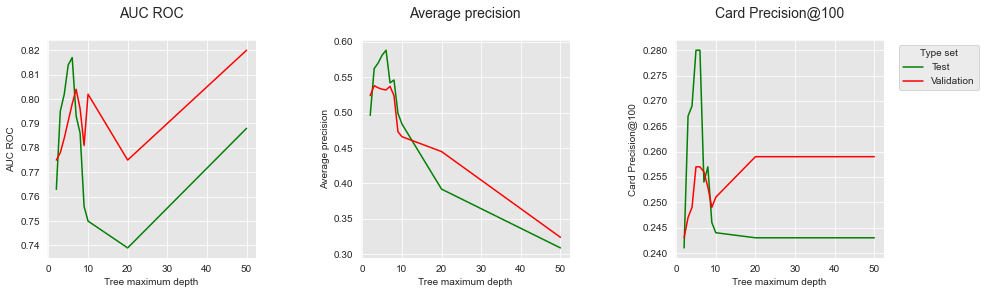

In [21]:
get_performances_plots(performances_df_validation, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'],expe_type_color_list=['#008000','#FF0000'])

Los gráficos muestran ideas interesantes sobre la capacidad del conjunto de validación para proporcionar tanto una buena estimación de rendimiento para el conjunto de prueba como una forma de seleccionar el mejor modelo. Primero, debe notarse que los rendimientos obtenidos en ambos conjuntos difieren en términos de valores exactos, pero tienden a seguir dinámicas similares. No se pueden esperar coincidencias exactas en términos de rendimientos, ya que se usan conjuntos diferentes para entrenamiento y prueba. 

Los rendimientos obtenidos en el conjunto de validación sin embargo proporcionan orientación para seleccionar las profundidades de árbol que pueden maximizar el rendimiento en el conjunto de prueba. Esto es particularmente cierto para el rendimiento en términos de AP, donde la profundidad óptima está en el rango de 3 a 8. 

El AUC ROC y CP@100 sin embargo exhiben más discrepancias, y parecen menos bien adaptados para determinar la profundidad de árbol óptima. En particular, su valor se maximiza en el conjunto de validación para una profundidad de árbol de decisión de 50, mientras que tal profundidad de árbol proporciona un rendimiento bajo en el conjunto de prueba.

## Validación hold-out repetida

Los modelos de predicción, y sus rendimientos, a menudo son sensibles a los datos usados para entrenamiento. Cambiar ligeramente el conjunto de entrenamiento puede resultar en diferentes modelos de predicción y rendimientos. 

Una alternativa a los procedimientos de validación hold-out consiste en entrenar diferentes modelos de predicción con muestras aleatorias de los datos de entrenamiento. Esto permite obtener diferentes estimaciones del error de validación, proporcionando por lo tanto intervalos de confianza sobre los rendimientos esperados, en lugar de una sola estimación. El procedimiento se conoce como el procedimiento de validación *hold-out repetida*.

La validación hold-out repetida se puede implementar modificando ligeramente la función `get_performances_train_test_sets` definida arriba. La función toma dos parámetros más:

* `n_folds`: El número de subconjuntos aleatorios que se usarán para entrenar los diferentes modelos de predicción
* `sampling_ratio`: La proporción de datos que se muestrearán aleatoriamente cada vez de los datos de entrenamiento.


In [24]:
def repeated_holdout_validation(transactions_df, classifier, 
                                start_date_training, 
                                delta_train=7, delta_delay=7, delta_test=7,
                                n_folds=4,
                                sampling_ratio=0.7,
                                top_k_list=[100],
                                type_test="Test", parameter_summary=""):

    performances_df_folds=pd.DataFrame()
    
    start_time=time.time() 
    
    for fold in range(n_folds):
        
        # Get the training and test sets
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test,
                                               sampling_ratio=sampling_ratio,
                                               random_state=fold)
    
        
        # Fit model  
        model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                         input_features, output_feature)
        
        # Compute fraud detection performances
        test_df['predictions']=model_and_predictions_dictionary['predictions_test']
        performances_df_test=performance_assessment(test_df, top_k_list=top_k_list)
        performances_df_test.columns=performances_df_test.columns.values+' '+type_test
        
        train_df['predictions']=model_and_predictions_dictionary['predictions_train']
        performances_df_train=performance_assessment(train_df, top_k_list=top_k_list)
        performances_df_train.columns=performances_df_train.columns.values+' Train'
    
        performances_df_folds=performances_df_folds.append(pd.concat([performances_df_test,performances_df_train],axis=1))
    
    execution_time=time.time()-start_time
    
    performances_df_folds_mean=performances_df_folds.mean()
    performances_df_folds_std=performances_df_folds.std(ddof=0)
    
    performances_df_folds_mean=pd.DataFrame(performances_df_folds_mean).transpose()
    performances_df_folds_std=pd.DataFrame(performances_df_folds_std).transpose()
    performances_df_folds_std.columns=performances_df_folds_std.columns.values+" Std"
    performances_df=pd.concat([performances_df_folds_mean,performances_df_folds_std],axis=1)
    
    performances_df['Execution time']=execution_time
    
    performances_df['Parameters summary']=parameter_summary
    
    return performances_df, performances_df_folds


Calculemos por ejemplo la precisión de validación con un árbol de decisión de profundidad 2.

In [25]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

performances_df_repeated_holdout_summary, \
performances_df_repeated_holdout_folds=repeated_holdout_validation(
    transactions_df, classifier, 
    start_date_training=start_date_training_with_valid, 
    delta_train=delta_train, 
    delta_delay=delta_delay, 
    delta_test=delta_test, 
    n_folds=4,
    sampling_ratio=0.7,
    type_test="Validation", parameter_summary='2'
)

La función `repeated_holdout_validation` devuelve dos DataFrames:

* `performances_df_repeated_holdout_summary`: Resumen de métricas de rendimiento sobre todos los folds, en términos de media y varianza estándar para cada métrica de rendimiento.
* `accuracy_df_repeated_holdout_folds`: Métricas de rendimiento obtenidas en cada fold

In [26]:
performances_df_repeated_holdout_summary

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Validation Std,Average precision Validation Std,Card Precision@100 Validation Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary
0,0.776,0.51875,0.24475,0.79475,0.57575,0.2985,0.001225,0.006495,0.001785,0.003961,0.008871,0.009341,3.287545,2


In [27]:
performances_df_repeated_holdout_folds

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train
0,0.778,0.514,0.247,0.797,0.569,0.311
0,0.776,0.511,0.246,0.798,0.572,0.304
0,0.775,0.523,0.243,0.788,0.571,0.289
0,0.775,0.527,0.243,0.796,0.591,0.290


Calculemos entonces los rendimientos esperados para diferentes profundidades de árboles de decisión (con valores $[2,3,4,5,6,7,8,9,10,20,50]$).

In [28]:
list_params = [2,3,4,5,6,7,8,9,10,20,50]

performances_df_repeated_holdout=pd.DataFrame()

start_time=time.time()

for max_depth in list_params:
    
    print("Computing performances for a decision tree with max_depth="+str(max_depth))
    
    classifier = sklearn.tree.DecisionTreeClassifier(max_depth = max_depth, random_state=0)

    performances_df_repeated_holdout=performances_df_repeated_holdout.append(
        repeated_holdout_validation(
            transactions_df, classifier, 
            start_date_training=start_date_training_with_valid, 
            delta_train=delta_train, 
            delta_delay=delta_delay, 
            delta_test=delta_test,
            n_folds=4,
            sampling_ratio=0.7,
            type_test="Validation", parameter_summary=max_depth
        )[0]
    )
    
performances_df_repeated_holdout.reset_index(inplace=True,drop=True)

print("Total execution time: "+str(round(time.time()-start_time,2))+"s")


Computing performances for a decision tree with max_depth=2
Computing performances for a decision tree with max_depth=3
Computing performances for a decision tree with max_depth=4
Computing performances for a decision tree with max_depth=5
Computing performances for a decision tree with max_depth=6
Computing performances for a decision tree with max_depth=7
Computing performances for a decision tree with max_depth=8
Computing performances for a decision tree with max_depth=9
Computing performances for a decision tree with max_depth=10
Computing performances for a decision tree with max_depth=20
Computing performances for a decision tree with max_depth=50
Total execution time: 39.19s


In [30]:
performances_df_repeated_holdout

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Validation Std,Average precision Validation Std,Card Precision@100 Validation Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary
0,0.77600,0.51875,0.24475,0.79475,0.57575,0.29850,0.001225,0.006495,0.001785,0.003961,0.008871,0.009341,3.002673,2
1,0.78200,0.53800,0.24900,0.80650,0.60525,0.30675,0.002449,0.003937,0.001414,0.002958,0.003832,0.007189,2.892724,3
2,0.78550,0.54100,0.25125,0.81425,0.62325,0.31075,0.006185,0.007649,0.006180,0.004969,0.006220,0.007790,3.032751,4
3,0.78200,0.52900,0.24825,0.82025,0.63625,0.31175,0.008515,0.014036,0.003700,0.007529,0.009575,0.008871,3.156154,5
4,0.78350,0.51725,0.25225,0.82875,0.64800,0.31825,0.007018,0.006300,0.005761,0.007395,0.008062,0.006759,3.217496,6
5,0.78450,0.51725,0.25175,0.83825,0.66375,0.32250,0.005025,0.015833,0.003491,0.002773,0.010779,0.005500,3.332991,7
6,0.78700,0.51150,0.25125,0.84625,0.67950,0.32400,0.009274,0.020267,0.002681,0.002861,0.003905,0.006285,3.418987,8
7,0.78400,0.50150,0.24850,0.85625,0.69000,0.32625,0.010700,0.024005,0.003841,0.011584,0.005244,0.005890,3.500675,9
8,0.79675,0.49800,0.25075,0.87400,0.70425,0.33000,0.015352,0.024321,0.003112,0.009192,0.007562,0.008832,3.656681,10
9,0.80125,0.45425,0.26300,0.97150,0.86500,0.37025,0.014289,0.030938,0.004637,0.008789,0.016837,0.011099,4.784067,20


For better vizualization, let us plot the validation and test accuracies in terms of AUC ROC, AP, and CP@100 as a function of the decision tree depth. 

In [31]:
performances_df

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.763,0.496,0.241,0.802,0.586,0.394,0.468689,2
1,0.795,0.562,0.267,0.815,0.615,0.409,0.582330,3
2,0.802,0.570,0.269,0.829,0.635,0.411,0.550253,4
3,0.814,0.581,0.280,0.835,0.649,0.419,0.580715,5
4,0.817,0.588,0.280,0.842,0.662,0.421,0.642127,6
5,0.793,0.542,0.254,0.876,0.679,0.427,0.666566,7
6,0.786,0.546,0.257,0.884,0.717,0.436,0.727614,8
7,0.756,0.499,0.246,0.896,0.737,0.437,0.773424,9
8,0.750,0.484,0.244,0.901,0.756,0.440,0.782423,10
9,0.739,0.392,0.243,0.974,0.907,0.506,1.194687,20


In [32]:
performances_df_repeated_holdout['AUC ROC Test']=performances_df['AUC ROC Test']
performances_df_repeated_holdout['Average precision Test']=performances_df['Average precision Test']
performances_df_repeated_holdout['Card Precision@100 Test']=performances_df['Card Precision@100 Test']


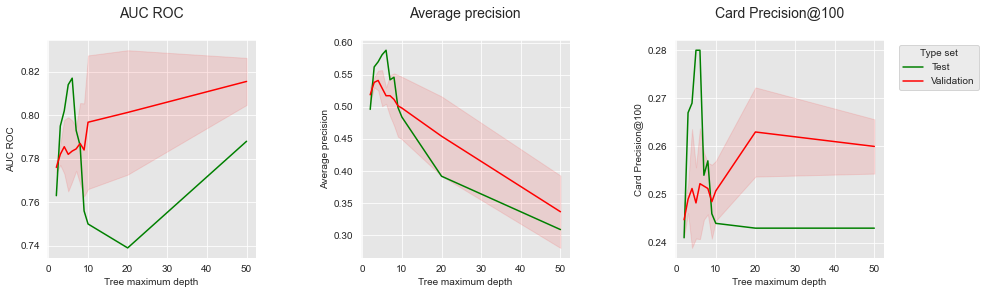

In [33]:
get_performances_plots(
    performances_df_repeated_holdout, 
    performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
    expe_type_list=['Test','Validation'],expe_type_color_list=['#008000','#FF0000']
)

La validación hold-out repetida ofrece una mejor vista de los rendimientos esperados, proporcionando intervalos de confianza. Cualitativamente, los resultados son similares a la validación hold-out. El AP proporciona el proxy más preciso al rendimiento esperado en el conjunto de prueba. El AUC ROC y CP@100 proporcionan estimaciones más pobres del rendimiento de prueba.



(Prequential_validation)=
## Validación prequencial

La validación hold-out repetida se basa en subconjuntos aleatorios de los mismos datos de entrenamiento para construir modelos de predicción. Una limitación de este enfoque es que reduce los rendimientos esperados de los modelos, ya que solo se usan subconjuntos de datos para entrenamiento. 

Un procedimiento de validación alternativo consiste en usar conjuntos de entrenamiento de tamaños similares, tomados de datos históricos más antiguos. El esquema se llama *validación prequencial*, y se ilustra en la Fig. 5. Cada fold desplaza los conjuntos de entrenamiento y validación por un bloque en el pasado. 

![alt text](images/stream_prequential_1block.png)
<div align="center">Fig. 5. Validación prequencial: Cada fold desplaza los conjuntos de entrenamiento y validación por un bloque en el pasado. El conjunto de validación tiene la misma longitud que el de prueba.</div>

La implementación es similar a la validación hold-out repetida. La única diferencia es que, para cada fold, las fechas de inicio para los conjuntos de entrenamiento y validación se desplazan por un bloque. La implementación se proporciona a continuación, con la función `prequential_validation`. 


In [34]:
def prequential_validation(transactions_df, classifier, 
                           start_date_training, 
                           delta_train=7, 
                           delta_delay=7, 
                           delta_assessment=7,
                           n_folds=4,
                           top_k_list=[100],
                           type_test="Test", parameter_summary=""):

    performances_df_folds=pd.DataFrame()
    
    start_time=time.time() 
    
    for fold in range(n_folds):
        
        start_date_training_fold=start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Get the training and test sets
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,
                                               delta_delay=delta_delay,
                                               delta_test=delta_assessment)
    
        # Fit model
        model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                     input_features, output_feature)
        
        # Compute fraud detection performances    
        test_df['predictions']=model_and_predictions_dictionary['predictions_test']
        performances_df_test=performance_assessment(test_df, top_k_list=top_k_list, rounded=False)
        performances_df_test.columns=performances_df_test.columns.values+' '+type_test
        
        train_df['predictions']=model_and_predictions_dictionary['predictions_train']
        performances_df_train=performance_assessment(train_df, top_k_list=top_k_list, rounded=False)
        performances_df_train.columns=performances_df_train.columns.values+' Train'
    
        performances_df_folds=performances_df_folds.append(pd.concat([performances_df_test,performances_df_train],axis=1))
    
    execution_time=time.time()-start_time
    
    performances_df_folds_mean=performances_df_folds.mean()
    performances_df_folds_std=performances_df_folds.std(ddof=0)
    
    performances_df_folds_mean=pd.DataFrame(performances_df_folds_mean).transpose()
    performances_df_folds_std=pd.DataFrame(performances_df_folds_std).transpose()
    performances_df_folds_std.columns=performances_df_folds_std.columns.values+" Std"
    performances_df=pd.concat([performances_df_folds_mean,performances_df_folds_std],axis=1)
    
    performances_df['Execution time']=execution_time
    
    performances_df['Parameters summary']=parameter_summary
    
    return performances_df, performances_df_folds


Calculemos por ejemplo el rendimiento de validación con un árbol de decisión de profundidad 2.


In [35]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

performances_df_prequential_summary, performances_df_prequential_folds=prequential_validation(
    transactions_df, classifier, 
    start_date_training=start_date_training_with_valid, 
    delta_train=delta_train, 
    delta_delay=delta_delay, 
    delta_assessment=delta_valid, 
    n_folds=4,
    type_test="Validation", parameter_summary='2'
)

Como con la función `repeated_holdout_validation`, la función `prequential_validation` devuelve dos DataFrames:

* `performances_df_prequential_summary`: Resumen de métricas de rendimiento sobre todos los folds, en términos de media y varianza estándar para cada métrica de rendimiento.
* `performances_df_prequential_folds`: Métricas de rendimiento obtenidas en cada fold

In [36]:
performances_df_prequential_summary

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Validation Std,Average precision Validation Std,Card Precision@100 Validation Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary
0,0.790786,0.549767,0.256429,0.804231,0.593561,0.4025,0.012035,0.022134,0.014481,0.013359,0.018224,0.040474,3.364997,2


In [37]:
performances_df_prequential_folds

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train
0,0.775012,0.523548,0.242857,0.791004,0.576732,0.398571
0,0.808739,0.584663,0.242857,0.791234,0.576985,0.347143
0,0.791405,0.542531,0.262857,0.813726,0.599954,0.402857
0,0.787988,0.548326,0.277143,0.820960,0.620572,0.461429


Calculemos entonces los rendimientos esperados para diferentes profundidades de árboles de decisión, que van desde $[2,3,4,5,6,7,8,9,10,20,50]$.

In [38]:
list_params = [2,3,4,5,6,7,8,9,10,20,50]

start_time=time.time()

performances_df_prequential=pd.DataFrame()

for max_depth in list_params:
    
    print("Computing performances for a decision tree with max_depth="+str(max_depth))
    
    classifier = sklearn.tree.DecisionTreeClassifier(max_depth = max_depth, random_state=0)

    performances_df_prequential=performances_df_prequential.append(
        prequential_validation(
            transactions_df, classifier,
            start_date_training=start_date_training_with_valid, 
            delta_train=delta_train, 
            delta_delay=delta_delay, 
            delta_assessment=delta_test,
            n_folds=4,
            type_test="Validation", parameter_summary=max_depth
        )[0]
    )
    
performances_df_prequential.reset_index(inplace=True,drop=True)

print("Total execution time: "+str(round(time.time()-start_time,2))+"s")


Computing performances for a decision tree with max_depth=2
Computing performances for a decision tree with max_depth=3
Computing performances for a decision tree with max_depth=4
Computing performances for a decision tree with max_depth=5
Computing performances for a decision tree with max_depth=6
Computing performances for a decision tree with max_depth=7
Computing performances for a decision tree with max_depth=8
Computing performances for a decision tree with max_depth=9
Computing performances for a decision tree with max_depth=10
Computing performances for a decision tree with max_depth=20
Computing performances for a decision tree with max_depth=50
Total execution time: 52.82s


In [39]:
performances_df_prequential

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Validation Std,Average precision Validation Std,Card Precision@100 Validation Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary
0,0.790786,0.549767,0.256429,0.804231,0.593561,0.402500,0.012035,0.022134,0.014481,0.013359,0.018224,0.040474,3.666392,2
1,0.802717,0.573414,0.267143,0.818140,0.623562,0.421429,0.017607,0.027186,0.016067,0.011437,0.016412,0.032214,3.414093,3
2,0.800690,0.554134,0.264286,0.825978,0.644766,0.426429,0.017878,0.038293,0.014321,0.009928,0.018337,0.034144,3.765976,4
3,0.804218,0.546094,0.267857,0.831289,0.657368,0.431429,0.016505,0.042197,0.013869,0.007867,0.016387,0.029881,3.788764,5
4,0.798603,0.537006,0.264643,0.839032,0.669597,0.432143,0.024225,0.037056,0.008474,0.002592,0.012448,0.028383,4.170064,6
5,0.795636,0.530609,0.262500,0.846446,0.681837,0.436429,0.023144,0.040323,0.006804,0.005559,0.008949,0.026351,4.368153,7
6,0.795142,0.516246,0.260714,0.859548,0.694885,0.440000,0.023081,0.033545,0.009715,0.008063,0.009498,0.031380,4.966671,8
7,0.785849,0.505189,0.260357,0.864869,0.717259,0.447500,0.026249,0.040393,0.009813,0.011527,0.015346,0.028453,4.757738,9
8,0.786784,0.493543,0.257143,0.887622,0.727672,0.448571,0.031165,0.048307,0.009949,0.011532,0.018154,0.028962,5.247802,10
9,0.780408,0.450980,0.264286,0.964275,0.862459,0.496786,0.022168,0.031413,0.007890,0.007512,0.014831,0.031483,6.802245,20


Grafiquemos los rendimientos de validación y prueba en términos de AUC ROC, AP, y CP@100, como una función de la profundidad del árbol de decisión. 

In [40]:
performances_df_prequential['AUC ROC Test']=performances_df['AUC ROC Test']
performances_df_prequential['Average precision Test']=performances_df['Average precision Test']
performances_df_prequential['Card Precision@100 Test']=performances_df['Card Precision@100 Test']


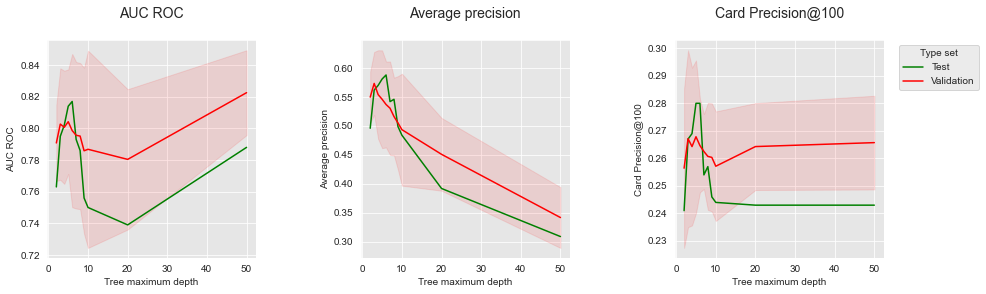

In [41]:
get_performances_plots(performances_df_prequential, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'])

También podemos calcular los rendimientos en las siguientes `n_folds` semanas usando el mismo código, pero estableciendo el día de inicio para entrenamiento de tal manera que se obtengan estimaciones para el período de prueba. Esto permite proporcionar intervalos de confianza para los rendimientos en los datos de prueba.

In [42]:
list_params = [2,3,4,5,6,7,8,9,10,20,50]

start_time=time.time()

n_folds=4

performances_df_prequential_test=pd.DataFrame()

for max_depth in list_params:
    
    classifier = sklearn.tree.DecisionTreeClassifier(max_depth = max_depth, random_state=0)

    performances_df_prequential_test=performances_df_prequential_test.append(
        prequential_validation(
            transactions_df, classifier, 
            start_date_training=start_date_training 
                +datetime.timedelta(days=delta_test*(n_folds-1)), 
            delta_train=delta_train, 
            delta_delay=delta_delay, 
            delta_assessment=delta_test,
            n_folds=n_folds,
            type_test="Test", parameter_summary=max_depth
        )[0]
    )
    
performances_df_prequential_test.reset_index(inplace=True,drop=True)

print("Total execution time: "+str(round(time.time()-start_time,2))+"s")


Total execution time: 53.54s


In [43]:
performances_df_prequential_test

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Test Std,Average precision Test Std,Card Precision@100 Test Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary
0,0.791909,0.541761,0.265000,0.807785,0.592120,0.394643,0.017769,0.031476,0.019756,0.011559,0.017914,0.004088,3.404004,2
1,0.809012,0.578885,0.281429,0.820076,0.623315,0.410714,0.009125,0.014434,0.015940,0.007795,0.015303,0.003712,3.928414,3
2,0.812555,0.601088,0.282500,0.829963,0.645225,0.412500,0.010319,0.020216,0.015199,0.006963,0.015748,0.005285,3.725971,4
3,0.810138,0.600306,0.284286,0.835835,0.658589,0.416071,0.008586,0.016797,0.004286,0.008285,0.015249,0.008353,4.961377,5
4,0.804437,0.585132,0.281429,0.847145,0.671259,0.420000,0.007974,0.005053,0.007626,0.007900,0.016706,0.006145,4.066389,6
5,0.782710,0.554860,0.268929,0.859658,0.692724,0.427500,0.012483,0.011771,0.009813,0.013379,0.012199,0.012990,4.978631,7
6,0.774783,0.544933,0.263571,0.865567,0.708766,0.429643,0.014568,0.003392,0.007593,0.015050,0.009896,0.012951,4.452925,8
7,0.761763,0.520208,0.258571,0.877844,0.721114,0.431786,0.012098,0.012309,0.009949,0.012280,0.014920,0.012792,5.070283,9
8,0.758138,0.504909,0.257500,0.881659,0.737896,0.435357,0.011140,0.013154,0.010467,0.012795,0.012402,0.012990,5.592131,10
9,0.754024,0.439422,0.261071,0.969552,0.878847,0.491429,0.009848,0.034828,0.014335,0.010886,0.026480,0.021500,6.487757,20


Grafiquemos las precisiones de validación y prueba en términos de AUC ROC, AP y CP@100, como una función de la profundidad del árbol de decisión. 

In [44]:
performances_df_prequential['AUC ROC Test']=performances_df_prequential_test['AUC ROC Test']
performances_df_prequential['Average precision Test']=performances_df_prequential_test['Average precision Test']
performances_df_prequential['Card Precision@100 Test']=performances_df_prequential_test['Card Precision@100 Test']
performances_df_prequential['AUC ROC Test Std']=performances_df_prequential_test['AUC ROC Test Std']
performances_df_prequential['Average precision Test Std']=performances_df_prequential_test['Average precision Test Std']
performances_df_prequential['Card Precision@100 Test Std']=performances_df_prequential_test['Card Precision@100 Test Std']


In [45]:
performances_df_prequential

,AUC ROC Validation,Average precision Validation,Card Precision@100 Validation,AUC ROC Train,Average precision Train,Card Precision@100 Train,AUC ROC Validation Std,Average precision Validation Std,Card Precision@100 Validation Std,AUC ROC Train Std,Average precision Train Std,Card Precision@100 Train Std,Execution time,Parameters summary,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Test Std,Average precision Test Std,Card Precision@100 Test Std
0,0.790786,0.549767,0.256429,0.804231,0.593561,0.402500,0.012035,0.022134,0.014481,0.013359,0.018224,0.040474,3.666392,2,0.791909,0.541761,0.265000,0.017769,0.031476,0.019756
1,0.802717,0.573414,0.267143,0.818140,0.623562,0.421429,0.017607,0.027186,0.016067,0.011437,0.016412,0.032214,3.414093,3,0.809012,0.578885,0.281429,0.009125,0.014434,0.015940
2,0.800690,0.554134,0.264286,0.825978,0.644766,0.426429,0.017878,0.038293,0.014321,0.009928,0.018337,0.034144,3.765976,4,0.812555,0.601088,0.282500,0.010319,0.020216,0.015199
3,0.804218,0.546094,0.267857,0.831289,0.657368,0.431429,0.016505,0.042197,0.013869,0.007867,0.016387,0.029881,3.788764,5,0.810138,0.600306,0.284286,0.008586,0.016797,0.004286
4,0.798603,0.537006,0.264643,0.839032,0.669597,0.432143,0.024225,0.037056,0.008474,0.002592,0.012448,0.028383,4.170064,6,0.804437,0.585132,0.281429,0.007974,0.005053,0.007626
5,0.795636,0.530609,0.262500,0.846446,0.681837,0.436429,0.023144,0.040323,0.006804,0.005559,0.008949,0.026351,4.368153,7,0.782710,0.554860,0.268929,0.012483,0.011771,0.009813
6,0.795142,0.516246,0.260714,0.859548,0.694885,0.440000,0.023081,0.033545,0.009715,0.008063,0.009498,0.031380,4.966671,8,0.774783,0.544933,0.263571,0.014568,0.003392,0.007593
7,0.785849,0.505189,0.260357,0.864869,0.717259,0.447500,0.026249,0.040393,0.009813,0.011527,0.015346,0.028453,4.757738,9,0.761763,0.520208,0.258571,0.012098,0.012309,0.009949
8,0.786784,0.493543,0.257143,0.887622,0.727672,0.448571,0.031165,0.048307,0.009949,0.011532,0.018154,0.028962,5.247802,10,0.758138,0.504909,0.257500,0.011140,0.013154,0.010467
9,0.780408,0.450980,0.264286,0.964275,0.862459,0.496786,0.022168,0.031413,0.007890,0.007512,0.014831,0.031483,6.802245,20,0.754024,0.439422,0.261071,0.009848,0.034828,0.014335


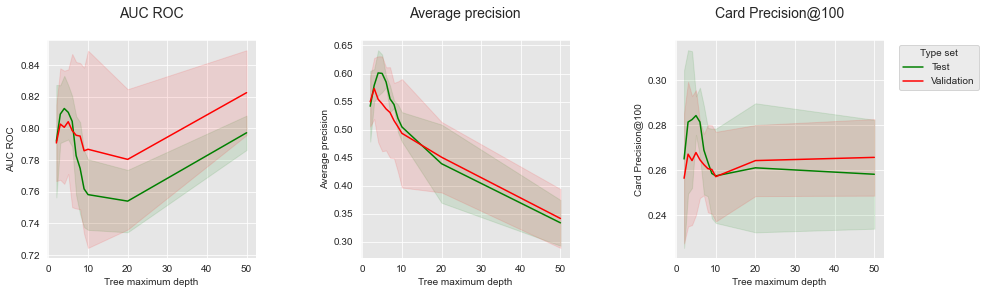

In [46]:
get_performances_plots(performances_df_prequential, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'])

El gráfico resultante muestra un mejor acuerdo entre los rendimientos de validación y prueba para las tres métricas de rendimiento. El AUC ROC sigue siendo problemático, ya que seleccionaría una profundidad de 50 como el mejor rendimiento para el conjunto de validación, mientras que las profundidades óptimas están en el rango de 3 a 6. El AP y CP@100 sin embargo siguen tendencias similares para los conjuntos de validación y prueba. 

La validación prequencial ofrece la forma más robusta de realizar la selección de modelos y será el enfoque preferido en el resto de este libro. Sin embargo, debe notarse que es computacionalmente intensiva ya que requiere la creación de varios modelos de predicción para cada parámetro de modelo probado.

(Sklearn_Validation_Pipeline)=
## Integración en Scikit-learn 

Scikit-learn (también conocido como *sklearn*) es la biblioteca de referencia para aprendizaje automático en Python. Dado que la validación y la selección de modelos son pasos esenciales en el diseño de modelos de predicción de aprendizaje automático, sklearn proporciona [una amplia gama de técnicas para evaluar y validar modelos de predicción](https://scikit-learn.org/stable/model_selection.html).

Sklearn sin embargo ofrece pocas posibilidades para realizar validación en datos secuenciales. En particular, la validación prequencial presentada en la sección anterior, y la métrica de Precisión de Tarjetas no se proporcionan.

Esta última sección tiene como objetivo cerrar esta brecha, agregando tanto la validación prequencial como la métrica CP a los pipelines de validación y selección de modelos proporcionados por sklearn. Los beneficios serán obtener acceso a funciones de alto nivel de la biblioteca sklearn. Estas incluyen, entre otras, la capacidad de 

* paralelizar fácilmente la ejecución de código
* confiar en *pipelines* de sklearn para transformación de datos
* confiar en diferentes estrategias para sintonización de hiperparámetros (búsqueda exhaustiva, búsqueda aleatoria, ...). 




### División prequencial

Scikit-learn proporciona siete estrategias diferentes para dividir datos para validación: `KFold`, `GroupKFold`, `ShuffleSplit`, `StratifiedKFold`, `GroupShuffleSplit`, `StratifiedShuffleSplit`, y `TimeSeriesSplit`. Una visualización de estas estrategias de división se proporciona [aquí](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html). Ninguna de estas permite la división prequencial de datos ilustrada en la Fig. 5.

Definamos una función `prequentialSplit`, que devuelve los índices de los conjuntos de entrenamiento y prueba para cada uno de los folds de una división prequencial. 


In [ ]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
    # Para cada fold
    for fold in range(n_folds):
        
        # Desplazar hacia atrás la fecha de inicio para entrenamiento por el índice del fold veces el período de evaluación (delta_assessment)
        # (Ver Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Obtener los conjuntos de entrenamiento y prueba (evaluación)
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
    
        # Obtener los índices de los dos conjuntos, y agregarlos a la lista de divisiones prequenciales
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices

### Precisión de Tarjetas top-k

Las métricas personalizadas se pueden implementar en sklearn gracias a la función factory [`make_scorer`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html). El cálculo de la Precisión de Tarjetas top-k requiere que la función de puntuación sea consciente del ID del cliente y el día de la transacción (ver Sección [Métricas de Precisión Top-K](Precision_Top_K_Metrics)). Esto se hace pasando el DataFrame `transactions_df` como argumento a la función. Más detalles sobre el diseño de funciones de puntuación personalizadas se pueden encontrar [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring).



In [ ]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Creemos un DataFrame predictions_df, que contiene todas las transacciones que coinciden con los índices del fold actual
    # (índices del vector y_true)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Calcular el CP@k usando la función implementada en el Capítulo 4, Sección 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Devolver el mean_card_precision_top_k
    return mean_card_precision_top_k

# Solo mantener columnas que se necesitan como argumento a la función de puntuación personalizada
# (para reducir el tiempo de serialización del conjunto de datos de transacciones)
transactions_df_scorer=transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

# Crear scorer usando card_precision_top_k_custom
card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)



### Búsqueda en cuadrícula

Sklearn permite automatizar el ajuste y la evaluación de modelos con diferentes hiperparámetros mediante la [función GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). 

Sus principales parámetros son

* `estimator`: El estimador a usar, que será un árbol de decisión en el siguiente ejemplo.
* `param_grid`: El conjunto de hiperparámetros para el estimador. Variaremos el parámetro de profundidad del árbol de decisión (`max_depth`), y estableceremos el estado aleatorio (`random_state`) para reproducibilidad.
* `scoring`: Las funciones de puntuación a usar. Usaremos el AUC ROC, Precisión Promedio, y CP@100.   
* `n_jobs`: El número de núcleos a usar. Lo estableceremos en -1, es decir, usar todos los núcleos disponibles. 
* `refit`: Si el modelo debe ajustarse con todos los datos después de la validación cruzada. Esto se establecerá en false, ya que solo requerimos los resultados de la validación cruzada.
* `cv`: La estrategia de división de validación cruzada. Se usará la validación prequencial, pasando los índices devueltos por la función `prequentialSplit`.

Establezcamos estos parámetros, e instanciemos un objeto `GridSearchCV`.

In [ ]:
# Estimator to use
classifier = sklearn.tree.DecisionTreeClassifier()

# Hyperparameters to test
parameters = {'clf__max_depth':[2,4], 'clf__random_state':[0]}

# Scoring functions. AUC ROC and Average Precision are readily available from sklearn 
# with `auc_roc` and `average_precision`. Card Precision@100 was implemented with the make_scorer factory function. 
scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100
           }

# A pipeline is created to scale data before fitting a model
estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
pipe = sklearn.pipeline.Pipeline(estimators)

# Indices for the prequential validation are obtained with the prequentialSplit function
prequential_split_indices = prequentialSplit(transactions_df,
                                             start_date_training_with_valid, 
                                             n_folds=n_folds,
                                             delta_train=delta_train, 
                                             delta_delay=delta_delay, 
                                             delta_assessment=delta_valid)

# Instanciemos el GridSearchCV
grid_search = sklearn.model_selection.GridSearchCV(pipe, param_grid=parameters, scoring=scoring, \
                                                   cv=prequential_split_indices, refit=False, n_jobs=-1,verbose=0)

# And select the input features, and output feature
X=transactions_df[input_features]
y=transactions_df[output_feature]



El ajuste y la evaluación se realizan llamando a la función `fit` del objeto `grid_search`.

In [50]:
# %time grid_search.fit(X, y)
# 
# print("Finished CV fitting")

CPU times: user 152 ms, sys: 259 ms, total: 411 ms
Wall time: 6.51 s
Finished CV fitting


Los resultados de la validación cruzada se pueden recuperar con el atributo `cv_results_`. Contiene la puntuación para cada fold y métricas de puntuación, junto con estadísticas sobre los tiempos de ejecución. 

In [51]:
grid_search.cv_results_

{'mean_fit_time': array([1.05854368, 1.27579147]),
 'std_fit_time': array([0.0081484 , 0.01675179]),
 'mean_score_time': array([0.29740781, 0.21103078]),
 'std_score_time': array([0.00725061, 0.00444517]),
 'param_clf__max_depth': masked_array(data=[2, 4],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_clf__random_state': masked_array(data=[0, 0],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'params': [{'clf__max_depth': 2, 'clf__random_state': 0},
  {'clf__max_depth': 4, 'clf__random_state': 0}],
 'split0_test_roc_auc': array([0.7750121 , 0.78393251]),
 'split1_test_roc_auc': array([0.80873906, 0.82871798]),
 'split2_test_roc_auc': array([0.79140481, 0.78643512]),
 'split3_test_roc_auc': array([0.78798838, 0.80367453]),
 'mean_test_roc_auc': array([0.79078609, 0.80069003]),
 'std_test_roc_auc': array([0.01203472, 0.01787799]),
 'rank_test_roc_auc': array([2, 1], dtype=int32),
 'split0_test_avera

Reorganicemos estos resultados en un formato más legible:

In [52]:
performances_df=pd.DataFrame()

expe_type="Validation"

performance_metrics_list_grid=['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100']


for i in range(len(performance_metrics_list_grid)):
    performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
    performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']

performances_df['Parameters']=list(grid_search.cv_results_['params'])


In [53]:
performances_df

,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Execution time,Parameters
0,0.790786,0.012035,0.549767,0.022134,0.256429,0.014481,1.058544,"{'clf__max_depth': 2, 'clf__random_state': 0}"
1,0.800690,0.017878,0.554134,0.038293,0.264286,0.014321,1.275791,"{'clf__max_depth': 4, 'clf__random_state': 0}"


### Integración

Los mismos resultados que en la [sección anterior](Prequential_validation) se pueden obtener usando `GridSearchCV`. Definamos primero una función `prequential_grid_search`, que implementa la búsqueda en cuadrícula como arriba: 

In [54]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df

        

Podemos estimar los rendimientos de validación de un modelo de árbol de decisión para diferentes profundidades estableciendo `start_date_training` a `start_date_training_with_valid`.

In [55]:
start_time=time.time()

classifier = sklearn.tree.DecisionTreeClassifier()

parameters = {'clf__max_depth':[2,3,4,5,6,7,8,9,10,20,50], 'clf__random_state':[0]}

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }

performances_df_validation=prequential_grid_search(
    transactions_df, classifier, 
    input_features, output_feature,
    parameters, scoring, 
    start_date_training=start_date_training_with_valid,
    n_folds=n_folds,
    expe_type='Validation',
    delta_train=delta_train, 
    delta_delay=delta_delay, 
    delta_assessment=delta_valid,
    performance_metrics_list_grid=performance_metrics_list_grid,
    performance_metrics_list=performance_metrics_list)

print("Validation: Total execution time: "+str(round(time.time()-start_time,2))+"s")


Validation: Total execution time: 21.65s


And the test performances by setting `start_date_training` accordingly.

In [56]:
start_time=time.time()

performances_df_test=prequential_grid_search(
    transactions_df, classifier, 
    input_features, output_feature,
    parameters, scoring, 
    start_date_training=start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test),
    n_folds=n_folds,
    expe_type='Test',
    delta_train=delta_train, 
    delta_delay=delta_delay, 
    delta_assessment=delta_test,
    performance_metrics_list_grid=performance_metrics_list_grid,
    performance_metrics_list=performance_metrics_list)

print("Test: Total execution time: "+str(round(time.time()-start_time,2))+"s")


Test: Total execution time: 21.02s


Concatenemos los rendimientos de validación y prueba en un solo DataFrame.

In [57]:
performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

In [58]:
# Use the max_depth as the label for plotting
parameters_dict=dict(performances_df['Parameters'])
max_depth=[parameters_dict[i]['clf__max_depth'] for i in range(len(parameters_dict))]
performances_df['Parameters summary']=max_depth

In [59]:
performances_df

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.791909,0.017769,0.541761,0.031476,0.265000,0.019756,"{'clf__max_depth': 2, 'clf__random_state': 0}",0.961201,0.790786,0.012035,0.549767,0.022134,0.256429,0.014481,2
1,0.809012,0.009125,0.578885,0.014434,0.281429,0.015940,"{'clf__max_depth': 3, 'clf__random_state': 0}",0.974105,0.802717,0.017607,0.573414,0.027186,0.267143,0.016067,3
2,0.812555,0.010319,0.601088,0.020216,0.282500,0.015199,"{'clf__max_depth': 4, 'clf__random_state': 0}",1.052066,0.800690,0.017878,0.554134,0.038293,0.264286,0.014321,4
3,0.810138,0.008586,0.600306,0.016797,0.284286,0.004286,"{'clf__max_depth': 5, 'clf__random_state': 0}",1.283144,0.804218,0.016505,0.546094,0.042197,0.267857,0.013869,5
4,0.804437,0.007974,0.585132,0.005053,0.281429,0.007626,"{'clf__max_depth': 6, 'clf__random_state': 0}",1.634223,0.798603,0.024225,0.537006,0.037056,0.264643,0.008474,6
5,0.782710,0.012483,0.554860,0.011771,0.268929,0.009813,"{'clf__max_depth': 7, 'clf__random_state': 0}",1.494083,0.795636,0.023144,0.530609,0.040323,0.262500,0.006804,7
6,0.774783,0.014568,0.544933,0.003392,0.263571,0.007593,"{'clf__max_depth': 8, 'clf__random_state': 0}",1.539149,0.795142,0.023081,0.516246,0.033545,0.260714,0.009715,8
7,0.761763,0.012098,0.520208,0.012309,0.258571,0.009949,"{'clf__max_depth': 9, 'clf__random_state': 0}",1.371046,0.785849,0.026249,0.505189,0.040393,0.260357,0.009813,9
8,0.758138,0.011140,0.504909,0.013154,0.257500,0.010467,"{'clf__max_depth': 10, 'clf__random_state': 0}",1.442724,0.786784,0.031165,0.493543,0.048307,0.257143,0.009949,10
9,0.754024,0.009848,0.439422,0.034828,0.261071,0.014335,"{'clf__max_depth': 20, 'clf__random_state': 0}",2.176944,0.780408,0.022168,0.450980,0.031413,0.264286,0.007890,20


Grafiquemos los rendimientos para una mejor visualización.

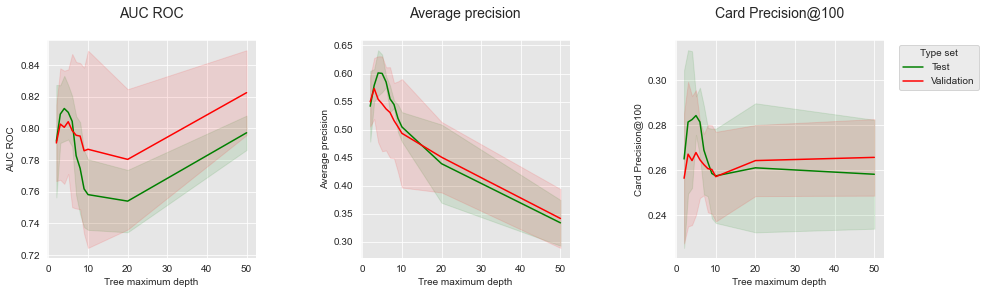

In [60]:
get_performances_plots(performances_df, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'],expe_type_color_list=['#008000','#FF0000'])

Los resultados son los mismos que los obtenidos en la Sección [Validación Prequencial](Prequential_Validation).


---

## ModelSelection


(Model_Selection)=
# Selección de modelos

La selección de modelos consiste en seleccionar el modelo de predicción que se espera que proporcione los mejores rendimientos en datos futuros. La metodología estándar consiste en cuatro pasos principales {cite}`bontempi2021statistical,bishop2006pattern,friedman2001elements`:

1. Definir una colección de modelos candidatos a probar. Sea $M$ el número de modelos, y $h_k$, $1 \le k \le M$, el modelo $k-$ésimo en la colección, parametrizado por un conjunto de parámetros $\theta_k$ (ver también la sección [Metodología baseline - Aprendizaje supervisado](ML_For_CCFD_Baseline_Methodology)). Dada una clase de modelos (como árboles de decisión, regresión logística, ...), una práctica común es definir una colección de modelos de complejidad creciente (profundidad del árbol para árboles de decisión, coeficientes de regularización para regresión logística, ...).  
2. Entrenar cada modelo candidato usando los datos de entrenamiento. El entrenamiento del modelo $h_k$ identifica los parámetros $\theta_k$ que maximizan los rendimientos de $h_k$ en el conjunto de entrenamiento.
3. Evaluar los rendimientos de cada modelo candidato mediante un procedimiento de validación (ver sección [Estrategias de Validación](Validation_Strategies)). El procedimiento de validación proporciona una estimación del rendimiento de generalización. Denotemos por $A_{valid}(h_k(.,\theta_k))$ el rendimiento de validación para el modelo $k$-ésimo. 
4. Seleccionar el modelo que tiene el mayor rendimiento de validación. Denotando por $k^*$ el índice de este modelo óptimo, tenemos:

$$
k^*= \mathrm{arg\ max}_{k \in \{1,2,...,M\}} A_{valid(h_k(.,\theta_k))}
$$

Una ilustración del procedimiento de selección de modelos con sus diferentes pasos se proporciona en la Fig. 1. 

![alt text](images/model_selection.png)
<div align="center">Fig. 1. Procedimiento de selección de modelos: Se entrena un conjunto de modelos de complejidad creciente, y sus rendimientos se evalúan usando un procedimiento de validación. Se selecciona el modelo que proporciona el mejor rendimiento de validación.</div>

La razón para evaluar modelos de complejidad creciente es que generalmente hay un equilibrio entre la complejidad del modelo y sus rendimientos de generalización (también conocido como el *equilibrio sesgo/varianza*) {cite}`bontempi2021statistical,bishop2006pattern,friedman2001elements`. Los modelos que tienen muy pocos parámetros fallan en representar adecuadamente la relación entre características de entrada y salida (también conocido como *subajuste*). Los modelos que tienen muchos parámetros pueden representar perfectamente la relación entre características de entrada y salida en los datos de entrenamiento (también conocido como *sobreajuste*). Los datos de entrenamiento sin embargo a menudo son ruidosos, y su distribución ligeramente diferente de los datos de validación y prueba. Como resultado, el sobreajuste generalmente es perjudicial para los rendimientos en los datos de validación o prueba. 

Una representación cualitativa del equilibrio entre complejidad del modelo y rendimientos se ilustra en la Fig. 2. Los rendimientos de entrenamiento generalmente aumentan con la complejidad del modelo. Los rendimientos óptimos de validación y prueba se encuentran para modelos de complejidad intermedia, que evitan tanto el subajuste como el sobreajuste. Este equilibrio se ilustró experimentalmente con árboles de decisión en la sección anterior sobre [Estrategias de Validación](Validation_Strategies).

![alt text](images/model_selection_graph.png)
<div align="center">Fig. 2. Equilibrio entre complejidad del modelo y rendimientos. Los rendimientos óptimos de validación y prueba generalmente se encuentran para modelos de complejidad intermedia, que evitan tanto el subajuste como el sobreajuste. </div>

Esta sección tiene como objetivo refinar el [pipeline de validación sklearn](Sklearn_Validation_Pipeline), y explorar los equilibrios entre complejidad del modelo y rendimientos para diferentes clases de modelos. 


In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 31568  100 31568    0     0  83513      0 --:--:-- --:--:-- --:--:-- 83513


(Model_Selection_Decision_Tree)=
## Selección de modelos: Árboles de decisión

Reproduzcamos primero el [pipeline de validación prequencial sklearn](Sklearn_Validation_Pipeline) propuesto en la sección anterior. Cargamos tres meses de datos de transacciones, y definimos la característica de salida como la etiqueta de fraude `TX_FRAUD`, y las características de entrada como el conjunto de características obtenidas del [preprocesamiento baseline](Baseline_Feature_Transformation).


In [2]:
# Load data from the 2018-06-11 to the 2018-09-14

DIR_INPUT = 'simulated-data-transformed/data/' 

BEGIN_DATE = "2018-06-11"
END_DATE = "2018-09-14"

print("Load  files")
%time transactions_df = read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

output_feature = "TX_FRAUD"

input_features = ['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


Load  files
CPU times: user 880 ms, sys: 545 ms, total: 1.43 s
Wall time: 1.66 s
919767 transactions loaded, containing 8195 fraudulent transactions


La fecha de inicio de referencia para entrenamiento se establece en 2018-07-25, y los deltas a siete días (ver [Estrategias de Validación](Validation_Strategies)). 

In [3]:
# Number of folds for the prequential validation
n_folds = 4

# Set the starting day for the training period, and the deltas
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = delta_valid = delta_assessment = 7

start_date_training_for_valid = start_date_training+datetime.timedelta(days=-(delta_delay+delta_valid))
start_date_training_for_test = start_date_training+datetime.timedelta(days=(n_folds-1)*delta_test)


Las métricas de rendimiento son el AUC ROC, la Precisión Promedio, y la Precisión de Tarjetas@100. 

In [4]:
# Only keep columns that are needed as argument to the custom scoring function
# (in order to reduce the serialization time of transaction dataset)
transactions_df_scorer = transactions_df[['CUSTOMER_ID', 'TX_FRAUD','TX_TIME_DAYS']]

card_precision_top_100 = sklearn.metrics.make_scorer(card_precision_top_k_custom, 
                                                     needs_proba=True, 
                                                     top_k=100, 
                                                     transactions_df=transactions_df_scorer)

performance_metrics_list_grid = ['roc_auc', 'average_precision', 'card_precision@100']
performance_metrics_list = ['AUC ROC', 'Average precision', 'Card Precision@100']

scoring = {'roc_auc':'roc_auc',
           'average_precision': 'average_precision',
           'card_precision@100': card_precision_top_100,
           }


For the sake of conciseness, let us define a `model_selection_wrapper` function, that will perform prequential validation for both the validation and the test sets. 

In [5]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


La validación prequencial ahora se puede realizar con las siguientes líneas de código, mediante

* definir qué clasificador usar
* definir qué parámetros probar
* ajustar los modelos y evaluar los rendimientos

La implementación usando árboles de decisión como modelos de predicción, para profundidad máxima en $[2,3,4,5,6,7,8,9,10,20,50]$, se obtiene con:

In [6]:
# Define classifier
classifier = sklearn.tree.DecisionTreeClassifier()

# Set of parameters for which to assess model performances
parameters = {'clf__max_depth':[2,3,4,5,6,7,8,9,10,20,50], 'clf__random_state':[0]}

start_time = time.time()

# Fit models and assess performances for all parameters
performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_dt = time.time()-start_time

# Select parameter of interest (max_depth)
parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__max_depth'] for i in range(len(parameters_dict))]

# Rename to performances_df_dt for model performance comparison at the end of this notebook
performances_df_dt=performances_df


In [7]:
performances_df_dt

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.791909,0.017769,0.541761,0.031476,0.265000,0.019756,"{'clf__max_depth': 2, 'clf__random_state': 0}",0.383720,0.790786,0.012035,0.549767,0.022134,0.256429,0.014481,2
1,0.809012,0.009125,0.578885,0.014434,0.281429,0.015940,"{'clf__max_depth': 3, 'clf__random_state': 0}",0.425149,0.802717,0.017607,0.573414,0.027186,0.267143,0.016067,3
2,0.812555,0.010319,0.601088,0.020216,0.282500,0.015199,"{'clf__max_depth': 4, 'clf__random_state': 0}",0.467093,0.800690,0.017878,0.554134,0.038293,0.264286,0.014321,4
3,0.810138,0.008586,0.600306,0.016797,0.284286,0.004286,"{'clf__max_depth': 5, 'clf__random_state': 0}",0.510538,0.804218,0.016505,0.546094,0.042197,0.267857,0.013869,5
4,0.804437,0.007974,0.585132,0.005053,0.281429,0.007626,"{'clf__max_depth': 6, 'clf__random_state': 0}",0.600303,0.798603,0.024225,0.537006,0.037056,0.264643,0.008474,6
5,0.782710,0.012483,0.554860,0.011771,0.268929,0.009813,"{'clf__max_depth': 7, 'clf__random_state': 0}",0.664072,0.795636,0.023144,0.530609,0.040323,0.262500,0.006804,7
6,0.774783,0.014568,0.544933,0.003392,0.263571,0.007593,"{'clf__max_depth': 8, 'clf__random_state': 0}",0.792020,0.795142,0.023081,0.516246,0.033545,0.260714,0.009715,8
7,0.761763,0.012098,0.520208,0.012309,0.258571,0.009949,"{'clf__max_depth': 9, 'clf__random_state': 0}",0.719332,0.785849,0.026249,0.505189,0.040393,0.260357,0.009813,9
8,0.758138,0.011140,0.504909,0.013154,0.257500,0.010467,"{'clf__max_depth': 10, 'clf__random_state': 0}",0.765691,0.786784,0.031165,0.493543,0.048307,0.257143,0.009949,10
9,0.754024,0.009848,0.439422,0.034828,0.261071,0.014335,"{'clf__max_depth': 20, 'clf__random_state': 0}",1.195464,0.780408,0.022168,0.450980,0.031413,0.264286,0.007890,20


El DataFrame resultante proporciona los rendimientos en términos de AUC ROC, AP, y CP@100 para ambos conjuntos de validación y prueba. Las filas corresponden a rendimientos para una profundidad máxima dada de un árbol de decisión. 



Extraigamos de esta tabla la información más relevante, es decir, entradas que permitan responder las siguientes preguntas:

1. ¿Qué parámetro proporciona los mejores rendimientos en el conjunto de validación? 
2. ¿Cuál es el rendimiento en el conjunto de prueba usando este parámetro?
3. ¿Qué parámetro habría proporcionado el mejor rendimiento en el conjunto de prueba?

Las respuestas a estas preguntas se pueden organizar como una tabla, usando la función `get_summary_performances`.


In [ ]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    # Tres métricas de rendimiento
    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    # Reiniciar índices en caso de que se proporcione un subconjunto de un DataFrame de rendimiento como entrada
    performances_df.reset_index(drop=True,inplace=True)

    # Listas de parámetros/rendimientos que se recuperarán para los mejores parámetros estimados
    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    # Para cada métrica de rendimiento, obtener el rendimiento de validación y prueba para el mejor parámetro estimado
    for metric in metrics:
    
        # Encontrar el índice que proporciona el mejor rendimiento de validación
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        # Recuperar los parámetros correspondientes
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        # Agregar rendimiento de validación a la lista validation_performance (media+/-desv)
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        # Agregar rendimiento de prueba a la lista test_performance (media+/-desv)
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    # Agregar resultados al DataFrame performances_results
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    # Listas de parámetros/rendimientos que se recuperarán para los parámetros óptimos
    optimal_test_performance = []
    optimal_parameters = []

    # Para cada métrica de rendimiento, obtener el rendimiento para el parámetro óptimo
    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        # Encontrar el índice que proporciona el rendimiento óptimo
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        # Recuperar los parámetros correspondientes
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        # Agregar rendimiento de prueba a la lista test_performance (media+/-desv)
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    # Agregar resultados al DataFrame performances_results
    performances_results.loc["Optimal parameters"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results


In [9]:
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")
summary_performances_dt

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,50,3,5
Validation performance,0.823+/-0.01,0.573+/-0.03,0.268+/-0.01
Test performance,0.797+/-0.01,0.579+/-0.01,0.284+/-0.0
Optimal parameters,4,4,5
Optimal test performance,0.813+/-0.01,0.601+/-0.02,0.284+/-0.0


La primera fila proporciona los parámetros que maximizan los rendimientos en el conjunto de validación (mejores parámetros estimados $k^*$). La segunda y tercera filas proporcionan los rendimientos correspondientes en los conjuntos de validación y prueba, respectivamente. La cuarta fila proporciona los parámetros óptimos reales en el conjunto de prueba (los parámetros que maximizan los rendimientos en el conjunto de prueba). La quinta fila proporciona los rendimientos correspondientes en el conjunto de prueba. 

Se pueden hacer dos observaciones importantes de esta tabla resumen. Primero, el parámetro óptimo depende de las métricas de rendimiento: Es una profundidad máxima de 4 para AUC ROC y AP, mientras que es una profundidad máxima de 5 para el CP@100. Segundo, los mejores parámetros para la validación pueden no ser el parámetro óptimo para el conjunto de prueba. Este es el caso para el AUC ROC (profundidad máxima de 50 para el conjunto de validación versus 4 para el conjunto de prueba), y el AP (profundidad máxima de 3 para el conjunto de validación versus 4 para el conjunto de prueba). 

Similar a la sección [Estrategias de Validación](Validation_Strategies), grafiquemos los rendimientos como una función de la profundidad del árbol de decisión. La línea vertical punteada es la profundidad del árbol para la cual el rendimiento se maximiza en los datos de validación.


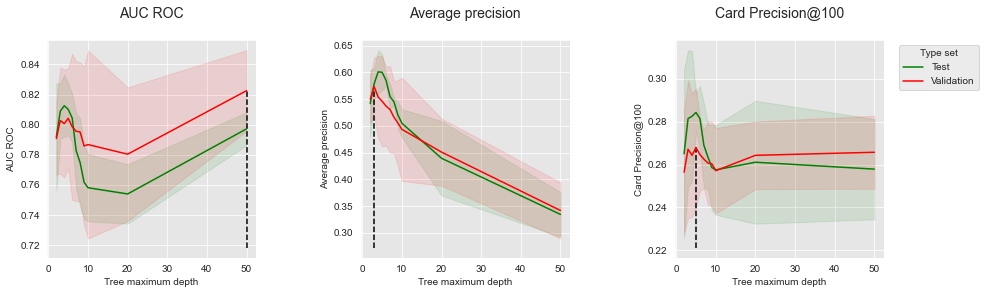

In [11]:
get_performances_plots(performances_df_dt, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       summary_performances=summary_performances_dt)

## Selección de modelos: Exploración de otras clases de modelos

Esta sección explora los rendimientos que se pueden lograr con selección de modelos usando otras clases de modelos. Cubrimos regresión logística, bosques aleatorios, y boosting (como en la sección [Sistema de Detección de Fraude Baseline](Baseline_FDS)).


(Model_Selection_Logistic_Regression)=
### Regresión logística

El hiperparámetro principal de la regresión logística es el [parámetro de regularización C](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression). El [valor por defecto para este parámetro es 1](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression). Intentemos ajustar modelos con valores más bajos y más altos, por ejemplo en el conjunto [0.1,1,10,100].   

In [12]:
classifier = sklearn.linear_model.LogisticRegression()

parameters = {'clf__C':[0.1,1,10,100], 'clf__random_state':[0]}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_lr = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[parameters_dict[i]['clf__C'] for i in range(len(parameters_dict))]

# Rename to performances_df_lr for model performance comparison at the end of this notebook
performances_df_lr=performances_df

In [13]:
performances_df_lr

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.866972,0.014858,0.620231,0.015977,0.297143,0.008207,"{'clf__C': 0.1, 'clf__random_state': 0}",0.602494,0.865052,0.009591,0.608330,0.022740,0.278929,0.016300,0.1
1,0.867643,0.015404,0.623081,0.016204,0.297143,0.008806,"{'clf__C': 1, 'clf__random_state': 0}",0.656055,0.866861,0.008988,0.612264,0.023474,0.278214,0.016914,1.0
2,0.867678,0.015415,0.623224,0.016087,0.297500,0.008828,"{'clf__C': 10, 'clf__random_state': 0}",0.582498,0.867050,0.008918,0.612526,0.023715,0.277500,0.016763,10.0
3,0.867680,0.015419,0.623253,0.016074,0.297500,0.008828,"{'clf__C': 100, 'clf__random_state': 0}",0.728584,0.867071,0.008912,0.612537,0.023712,0.277500,0.016763,100.0


La función `get_summary_performances` proporciona el resumen de los mejores parámetros y rendimientos correspondientes.

In [14]:
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")
summary_performances_lr

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100.0,100.0,0.1
Validation performance,0.867+/-0.01,0.613+/-0.02,0.279+/-0.02
Test performance,0.868+/-0.02,0.623+/-0.02,0.297+/-0.01
Optimal parameters,100.0,100.0,10.0
Optimal test performance,0.868+/-0.02,0.623+/-0.02,0.298+/-0.01


Grafiquemos los rendimientos como una función del valor de regularización, junto con el valor que proporciona los mejores rendimientos estimados.  

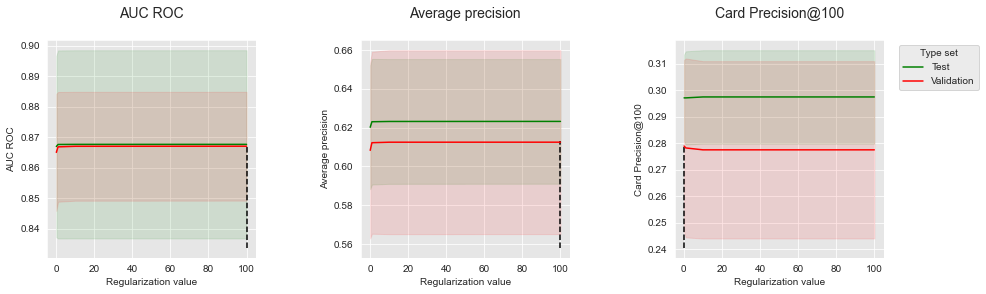

In [15]:
get_performances_plots(performances_df_lr, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Regularization value",
                       summary_performances=summary_performances_lr)

Los rendimientos tienden a ser un poco más bajos para un valor bajo de $C$ (0.1). Los valores de $C$ iguales o mayores que uno proporcionan rendimientos similares. El parámetro por defecto $C=1$ parece por lo tanto ser un valor sensato para el modelo de regresión logística. 

(Model_Selection_Random_Forest)=
### Bosque aleatorio

Los dos principales [hiperparámetros de un bosque aleatorio](https://scikit-learn.org/stable/modules/ensemble.html#forest) son la profundidad máxima del árbol y el número de árboles (parámetros `max_depth` y `n_estimators`, respectivamente). [Por defecto](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), la profundidad máxima del árbol es `None` (es decir, los nodos se expanden hasta que todas las hojas son puras o hasta que todas las hojas contienen menos de `min_samples_split` muestras), y el número de árboles es 100. Intentemos otros valores, combinando valores de `max_depth` en el conjunto [5,10,20,50] y valores de `n_estimators` en el conjunto [25,50,100].

In [16]:
classifier = sklearn.ensemble.RandomForestClassifier()

# Note: n_jobs set to one for getting true execution times
parameters = {'clf__max_depth':[5,10,20,50], 'clf__n_estimators':[25,50,100],
              'clf__random_state':[0],'clf__n_jobs':[1]}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_rf = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__n_estimators'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_depth'])
                                   for i in range(len(parameters_dict))]

# Rename to performances_df_rf for model performance comparison at the end of this notebook
performances_df_rf=performances_df


In [17]:
performances_df_rf

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.845287,0.003872,0.620712,0.022145,0.289286,0.010570,"{'clf__max_depth': 5, 'clf__n_estimators': 25,...",1.270088,0.834147,0.009100,0.610413,0.023740,0.274286,0.015551,25/5
1,0.850968,0.007508,0.620932,0.023824,0.290714,0.010996,"{'clf__max_depth': 5, 'clf__n_estimators': 50,...",2.229425,0.844140,0.007473,0.609801,0.027459,0.272857,0.015085,50/5
2,0.855230,0.007315,0.627034,0.021852,0.292500,0.010850,"{'clf__max_depth': 5, 'clf__n_estimators': 100...",4.209755,0.849065,0.011019,0.619450,0.026249,0.275000,0.016614,100/5
3,0.867271,0.006166,0.648583,0.012831,0.300714,0.010950,"{'clf__max_depth': 10, 'clf__n_estimators': 25...",2.068099,0.865000,0.002259,0.651858,0.020059,0.285357,0.012305,25/10
4,0.869225,0.007955,0.655050,0.014192,0.300000,0.012495,"{'clf__max_depth': 10, 'clf__n_estimators': 50...",3.791683,0.871323,0.004542,0.659386,0.021993,0.286786,0.015531,50/10
5,0.874949,0.011903,0.664613,0.014215,0.303214,0.013030,"{'clf__max_depth': 10, 'clf__n_estimators': 10...",7.230055,0.872388,0.005256,0.663481,0.024010,0.286429,0.017627,100/10
6,0.853581,0.014851,0.660131,0.013713,0.296429,0.012016,"{'clf__max_depth': 20, 'clf__n_estimators': 25...",3.181439,0.869824,0.005664,0.680407,0.016981,0.285357,0.014962,25/20
7,0.862653,0.016004,0.673352,0.011485,0.297143,0.013439,"{'clf__max_depth': 20, 'clf__n_estimators': 50...",6.027631,0.876311,0.006772,0.690434,0.019828,0.287143,0.016506,50/20
8,0.870378,0.016910,0.677675,0.011698,0.299286,0.013190,"{'clf__max_depth': 20, 'clf__n_estimators': 10...",11.521331,0.879728,0.006367,0.694063,0.020657,0.288571,0.016690,100/20
9,0.858527,0.008786,0.651899,0.009478,0.296429,0.010996,"{'clf__max_depth': 50, 'clf__n_estimators': 25...",3.340531,0.869956,0.003717,0.674013,0.021356,0.283929,0.016671,25/50


La función `get_summary_performances` proporciona el resumen de los mejores parámetros y rendimientos correspondientes.

In [18]:
summary_performances_rf=get_summary_performances(performances_df_rf, parameter_column_name="Parameters summary")
summary_performances_rf

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100/20,100/20,100/20
Validation performance,0.88+/-0.01,0.694+/-0.02,0.289+/-0.02
Test performance,0.87+/-0.02,0.678+/-0.01,0.299+/-0.01
Optimal parameters,100/10,100/20,100/10
Optimal test performance,0.875+/-0.01,0.678+/-0.01,0.303+/-0.01


Los mejores rendimientos se obtienen con bosques que contienen 100 árboles, con una profundidad máxima de 10 o 20. Los parámetros óptimos difieren de los mejores parámetros estimados para el AUC y CP@100. La diferencia en términos de rendimientos es sin embargo baja, y los mejores parámetros estimados pueden considerarse cercanos a los óptimos.

La visualización de los rendimientos como una función de los parámetros del modelo es más complicada ya que se varían dos parámetros. Fijemos primero el número de árboles, y luego variemos la profundidad máxima del árbol.

Fijando el número de árboles a 100, obtenemos:

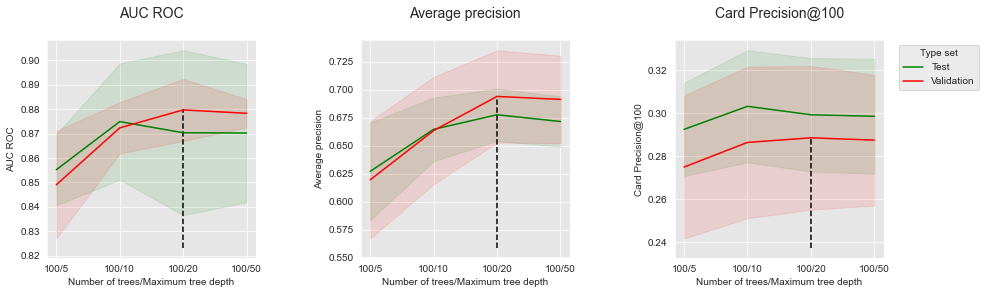

In [19]:
performances_df_rf_fixed_number_of_trees=performances_df_rf[performances_df_rf["Parameters summary"].str.startswith("100")]

summary_performances_fixed_number_of_trees=get_summary_performances(performances_df_rf_fixed_number_of_trees, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_rf_fixed_number_of_trees, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_number_of_trees)

Una profundidad máxima de árbol de 5 proporciona los rendimientos más bajos. Los rendimientos aumentan con la profundidad máxima del árbol, hasta una profundidad de árbol de 10 a 20 donde alcanzan una meseta y luego disminuyen ligeramente. 

Fijemos entonces la profundidad máxima del árbol, y variemos el número de estimadores. Fijando la profundidad máxima del árbol a 20, obtenemos:

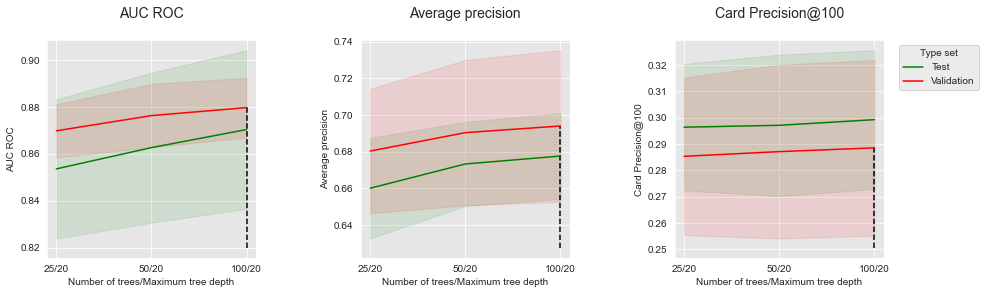

In [20]:
performances_df_rf_fixed_max_tree_depth=performances_df_rf[performances_df_rf["Parameters summary"].str.endswith("20")]

summary_performances_fixed_max_tree_depth=get_summary_performances(performances_df_rf_fixed_max_tree_depth, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_rf_fixed_max_tree_depth, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_max_tree_depth)

Para todas las métricas de rendimiento, la tendencia común es un aumento en los rendimientos a medida que se aumenta el número de árboles. Las ganancias de rendimiento agregadas sin embargo disminuyen con el número de árboles agregados. 

Vale la pena notar que los tiempos de ejecución para entrenar bosques aleatorios aumentan linealmente con el número de árboles. Esto se puede ilustrar graficando los tiempos de ejecución como una función del número de árboles.

In [21]:
# Get the performance plot for a single performance metric
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Plot data on graph
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Set title, and x and y axes labels
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")

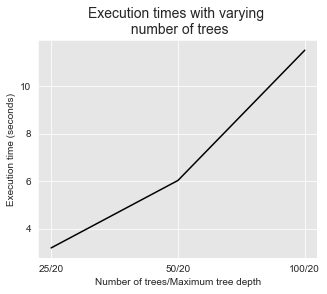

In [22]:
get_execution_times_plot(performances_df_rf_fixed_max_tree_depth, 
                         title="Execution times with varying \n number of trees",
                         parameter_name="Number of trees/Maximum tree depth")

Los tiempos de ejecución también aumentan con la profundidad máxima del árbol, como se ilustra a continuación. 

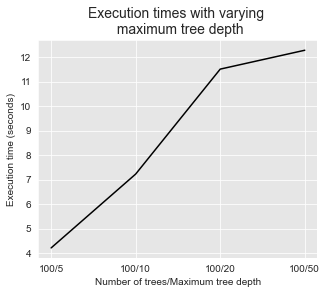

In [23]:
get_execution_times_plot(performances_df_rf_fixed_number_of_trees, 
                         title="Execution times with varying \n maximum tree depth",
                         parameter_name="Number of trees/Maximum tree depth")

All in all, the model selection procedure above took about 10 minutes to complete on one core, although only a small number of parameter combinations were tested (12 in total: 4 different parameters for the maximum tree depth, and 3 different parameters for the number of trees).

In [24]:
print("Total execution time for the model selection procedure: "+str(round(execution_time_rf,2))+"s")

Total execution time for the model selection procedure: 586.96s


Este ejemplo ilustra el equilibrio entre rendimiento y tiempos de computación en la búsqueda de parámetros óptimos. Los recursos computacionales generalmente están limitados, y se debe considerar cuidadosamente qué combinaciones de hiperparámetros se pueden probar dados los recursos disponibles. 

(Model_Selection_XGBoost)=
### XGBoost

XGBoost es un algoritmo de aprendizaje poderoso cuya sintonización sin embargo depende [de muchos hiperparámetros](https://xgboost.readthedocs.io/en/latest/python/python_api.html). Los más importantes son probablemente la profundidad máxima del árbol (`max_depth`), el número de árboles (`n_estimators`), y la tasa de aprendizaje (`learning_rate`). Por defecto, la profundidad máxima del árbol se establece en 6, el número de árboles en 100, y la tasa de aprendizaje en 0.3. Intentemos otras combinaciones, con `max_depth` en el conjunto [3,6,9], `n_estimators` en el conjunto [25,10,100], y `learning_rate` en el conjunto [0.1, 0.3].

In [10]:
classifier = xgboost.XGBClassifier()

parameters = {'clf__max_depth':[3,6,9], 'clf__n_estimators':[25,50,100], 'clf__learning_rate':[0.1, 0.3],
              'clf__random_state':[0], 'clf__n_jobs':[1], 'clf__verbosity':[0]}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        n_jobs=1)

execution_time_boosting = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__n_estimators'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__learning_rate'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_depth'])
                                   for i in range(len(parameters_dict))]

# Rename to performances_df_xgboost for model performance comparison at the end of this notebook
performances_df_xgboost=performances_df

In [25]:
performances_df_xgboost

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.833094,0.012257,0.635603,0.022225,0.296071,0.014859,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",2.740516,0.825157,0.009026,0.617990,0.025069,0.278214,0.015563,25/0.1/3
1,0.864766,0.006604,0.666130,0.012722,0.301429,0.013439,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",4.426460,0.863627,0.003203,0.651369,0.030279,0.280714,0.014932,50/0.1/3
2,0.870792,0.012352,0.694030,0.008394,0.303929,0.012305,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",7.717508,0.878438,0.009221,0.705235,0.019756,0.288214,0.015694,100/0.1/3
3,0.835862,0.012705,0.638601,0.025984,0.297500,0.014928,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",4.346976,0.843097,0.014918,0.640099,0.026283,0.278571,0.015551,25/0.1/6
4,0.871589,0.014202,0.686221,0.012026,0.301786,0.009603,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",8.303945,0.869654,0.002863,0.699780,0.016875,0.288214,0.016884,50/0.1/6
5,0.871278,0.011437,0.685991,0.008947,0.298571,0.010351,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",17.992388,0.881340,0.004587,0.706922,0.017461,0.286429,0.017217,100/0.1/6
6,0.852550,0.003171,0.656631,0.012632,0.302857,0.012164,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",4.437036,0.854345,0.008599,0.656910,0.023964,0.281429,0.012817,25/0.1/9
7,0.867596,0.016111,0.681919,0.011871,0.300000,0.009949,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",9.128478,0.875070,0.006199,0.700656,0.018366,0.285714,0.015779,50/0.1/9
8,0.862519,0.007472,0.674149,0.007838,0.293929,0.012428,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",18.618342,0.879667,0.003782,0.700592,0.017885,0.285000,0.017394,100/0.1/9
9,0.870988,0.014197,0.678544,0.012501,0.303214,0.012592,"{'clf__learning_rate': 0.3, 'clf__max_depth': ...",1.809805,0.877231,0.006120,0.698490,0.022835,0.288929,0.015131,25/0.3/3


La función `get_summary_performances` proporciona el resumen de los mejores parámetros y rendimientos correspondientes.

In [26]:
summary_performances_xgboost=get_summary_performances(performances_df_xgboost, parameter_column_name="Parameters summary")
summary_performances_xgboost

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100/0.3/3,50/0.3/3,25/0.3/3
Validation performance,0.887+/-0.01,0.708+/-0.02,0.289+/-0.02
Test performance,0.869+/-0.01,0.687+/-0.01,0.303+/-0.01
Optimal parameters,50/0.3/3,100/0.1/3,100/0.1/3
Optimal test performance,0.872+/-0.01,0.694+/-0.01,0.304+/-0.01


Los mejores parámetros obtenidos por validación son los mismos para ROC AUC, y difieren ligeramente para la precisión promedio y CP@100. Los rendimientos de prueba correspondientes son sin embargo similares.

Grafiquemos los rendimientos como una función de la profundidad máxima del árbol, para un número de árboles establecido en 100. Aumentar la profundidad máxima del árbol no afecta claramente los rendimientos. Aumenta ligeramente los rendimientos para AUC ROC y AP, pero disminuye ligeramente para CP@100.

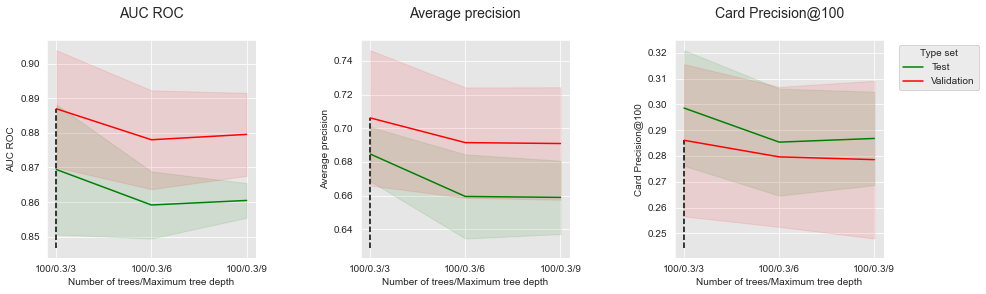

In [30]:
performances_df_xgboost_fixed_number_of_trees=performances_df_xgboost[performances_df_xgboost["Parameters summary"].str.startswith("100/0.3")]

summary_performances_fixed_number_of_trees=get_summary_performances(performances_df_xgboost_fixed_number_of_trees, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_xgboost_fixed_number_of_trees, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_number_of_trees)

Grafiquemos entonces los rendimientos como una función del número de árboles, para una profundidad máxima de árbol establecida en 5.

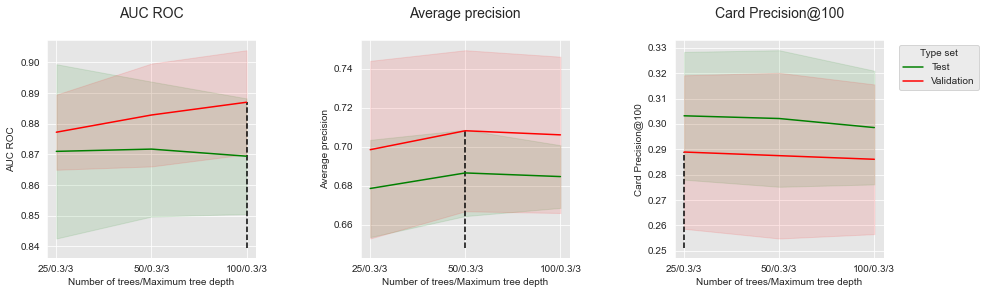

In [32]:
performances_df_xgboost_fixed_max_tree_depth=performances_df_xgboost[performances_df_xgboost["Parameters summary"].str.endswith("0.3/3")]

summary_performances_fixed_max_tree_depth=get_summary_performances(performances_df_xgboost_fixed_max_tree_depth, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_xgboost_fixed_max_tree_depth, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_max_tree_depth)

Aumentar el número de árboles de 25 a 50 permite aumentar los rendimientos para todas las métricas de rendimiento. Agregar más árboles sin embargo solo proporciona rendimientos ligeramente más altos para AUC ROC y AP, y disminuye ligeramente los rendimientos para CP@100. 

Similar a los bosques aleatorios, aumentar la profundidad máxima del árbol y el número de árboles tiene un costo en términos de tiempos de ejecución. Esto se ilustra en las dos figuras a continuación.

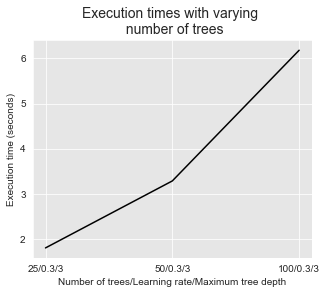

In [33]:
get_execution_times_plot(performances_df_xgboost_fixed_max_tree_depth, 
                         title="Execution times with varying \n number of trees",
                         parameter_name="Number of trees/Learning rate/Maximum tree depth")

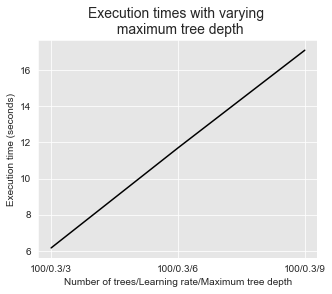

In [34]:
get_execution_times_plot(performances_df_xgboost_fixed_number_of_trees, 
                         title="Execution times with varying \n maximum tree depth",
                         parameter_name="Number of trees/Learning rate/Maximum tree depth")

El tiempo total de ejecución fue de más de 10 minutos usando un núcleo. 

In [35]:
print("Total execution time for the model selection procedure: "+str(round(execution_time_boosting,2))+"s")

Total execution time for the model selection procedure: 1251.2s


(Model_Selection_Comparison_Performances)=
## Comparación de rendimientos de modelos

La sección anterior detalló los rendimientos de diferentes clases de modelos. Comparemos estos rendimientos para determinar qué clase de modelo proporciona los mejores rendimientos. 

Para cada clase de modelo, recuperemos el rendimiento para tres tipos de parámetros:

* Parámetros por defecto: Parámetros por defecto que `sklearn` da a una clase de modelo. Los parámetros por defecto para cada clase de modelo son:
    * Árbol de decisión: `max_depth=None`.
    * Regresión logística: `C=1`.
    * Bosque aleatorio: `n_estimators=100`, `max_depth=None`.
    * XGBoost: `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`.
* Mejores parámetros estimados: Parámetros que proporcionan los mayores rendimientos en el conjunto de validación.
* Parámetros óptimos: Parámetros que proporcionan los mayores rendimientos en el conjunto de prueba.

La función `model_selection_performances` a continuación toma un diccionario de DataFrames de rendimiento y una métrica de rendimiento, y recupera los rendimientos correspondientes (media junto con desviación estándar). 
 

In [36]:
performances_df_dictionary={
    "Decision Tree": performances_df_dt,
    "Logistic Regression": performances_df_lr,
    "Random Forest": performances_df_rf,
    "XGBoost": performances_df_xgboost
}

In [ ]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.3/6"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Devolver los rendimientos medios y sus desviaciones estándar    
    return (mean_performances_dictionary,std_performances_dictionary)

Por ejemplo, ejecutar la función para la métrica AUC ROC devuelve:

In [40]:
model_selection_performances(performances_df_dictionary,
                             performance_metric='AUC ROC')

({'Default parameters': [0.797, 0.868, 0.87, 0.859],
  'Best validation parameters': [0.797, 0.868, 0.87, 0.869],
  'Optimal parameters': [0.813, 0.868, 0.875, 0.872]},
 {'Default parameters': [0.005, 0.015, 0.014, 0.005],
  'Best validation parameters': [0.01, 0.02, 0.02, 0.01],
  'Optimal parameters': [0.01, 0.02, 0.01, 0.01]})

Para una mejor visualización, grafiquemos los rendimientos para las cuatro clases de modelos y para cada métrica de rendimiento como gráficos de barras. La implementación se proporciona con `get_model_selection_performance_plot` y `get_model_selection_performances_plots` a continuación.

In [41]:
# Get the performance plot for a single performance metric
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # width of the bars
    barWidth = 0.3
    # The x position of bars
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Create Default parameters bars (Orange)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Create Best validation parameters bars (Red)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Create Optimal parameters bars (Green)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Set title, and x and y axes labels
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)

In [42]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

Esto da:

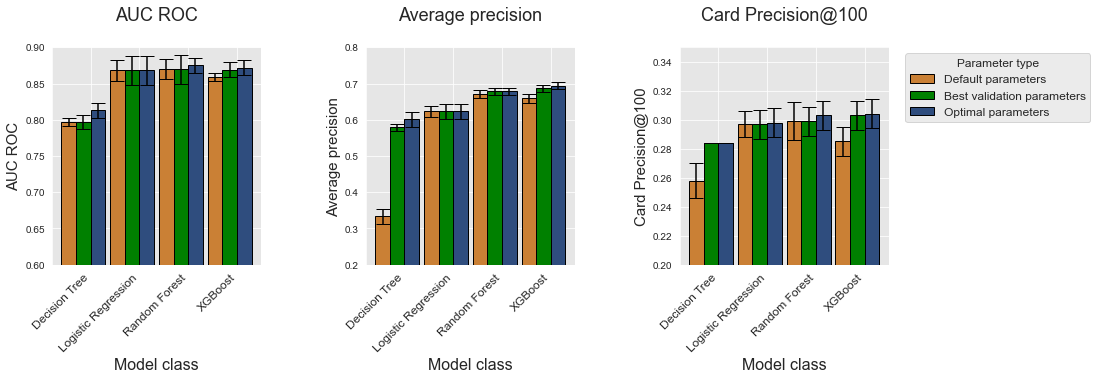

In [43]:
get_model_selection_performances_plots(performances_df_dictionary, 
                                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'])
    

En este conjunto de datos simulado, XGBoost proporciona los mayores rendimientos en términos de Precisión Promedio y CP@100, seguido por bosque aleatorio, regresión logística, y finalmente árboles de decisión que tienen los rendimientos más bajos. La brecha en términos de rendimiento es más visible con la métrica de precisión promedio. Los rendimientos de regresión logística, bosque aleatorio, y XGBoost son muy similares en términos de AUC ROC. 

Grafiquemos los tiempos totales de ejecución del procedimiento de selección de modelos para cada clase de modelo.

In [53]:
execution_times=[execution_time_dt,execution_time_lr,
                 execution_time_rf,execution_time_boosting]


In [55]:
# %%capture
# 
# fig_model_selection_execution_times_for_each_model_class, ax = plt.subplots(1, 1, figsize=(5,4))
# 
# model_classes=['Decision Tree','Logistic Regression','Random Forest','XGBoost']
#     
# # width of the bars
# barWidth = 0.3
# # The x position of bars
# r1 = np.arange(len(model_classes))
#     
# # Create execution times bars
# ax.bar(r1, execution_times[0:4], 
#         width = barWidth, color = 'black', edgecolor = 'black', 
#         capsize=7)
# 
# ax.set_xticks(r1+barWidth/2)
# ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
# ax.set_title('Model selection execution times \n for different model classes', fontsize=18)
# ax.set_xlabel("Model class", fontsize=16)
# ax.set_ylabel("Execution times (s)", fontsize=15)


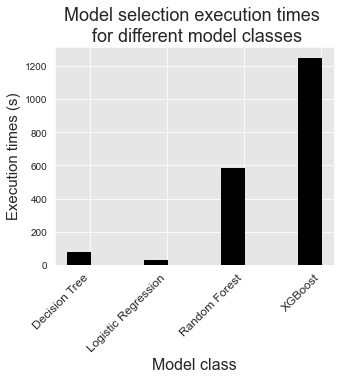

In [56]:
fig_model_selection_execution_times_for_each_model_class

La comparación en términos de tiempos de ejecución es principalmente cualitativa ya que dependen en gran medida del número de combinaciones de parámetros que se consideraron en el procedimiento de selección de modelos. Sin embargo, ilustra que la selección de modelos para modelos complejos como bosques aleatorios o boosting generalmente requiere más recursos computacionales, ya que requieren sintonizar un mayor número de hiperparámetros. 

## Búsqueda aleatoria

La búsqueda en cuadrícula es una estrategia ampliamente usada para la optimización de hiperparámetros. Sin embargo, rápidamente se vuelve intratable cuando el número de hiperparámetros es alto ya que el número de combinaciones de parámetros crece exponencialmente con el número de parámetros.

Una alternativa a la búsqueda en cuadrícula es la búsqueda aleatoria, donde se evalúan combinaciones aleatorias de parámetros para un número fijo de combinaciones. Además de permitir limitar el número de combinaciones de parámetros probadas, se ha demostrado tanto empírica como teóricamente que las combinaciones aleatorias son más eficientes para la optimización de hiperparámetros que la búsqueda en cuadrícula {cite}`bergstra2012random`. 

La intuición para la eficiencia de la búsqueda aleatoria se ilustra en la Fig. 3. Esencialmente, la búsqueda aleatoria permite explorar más eficientemente el espacio de hiperparámetros importantes.   

![alt text](images/random_search.png)
<div align="center">Fig. 3. Búsqueda en cuadrícula y aleatoria de nueve combinaciones de parámetros, en un espacio de dos parámetros. El rendimiento como una función de los valores de los parámetros se da en verde (arriba - parámetro importante) y amarillo (izquierda, parámetro no importante). La búsqueda en cuadrícula solo evalúa el parámetro importante para tres valores diferentes, mientras que la búsqueda aleatoria explora el parámetro importante para nueve valores diferentes (Figura tomada de {cite}`bergstra2012random`).</div>

La implementación de la búsqueda aleatoria en `sklearn` se puede realizar usando `RandomizedSearchCV` en lugar de `GridSearchCV` en la búsqueda prequencial. Modifiquemos la `prequential_grid_search` en una función más genérica `prequential_parameters_search`, agregando tres nuevos parámetros:

* `type_search`: Ya sea 'grid' para búsqueda en cuadrícula, o 'random' para búsqueda aleatoria.
* `n_iter`: Número de iteraciones (combinaciones de parámetros) para la búsqueda aleatoria.
* `random_state`: Estado aleatorio para reproducibilidad de la búsqueda aleatoria.


In [44]:
def prequential_parameters_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            type_search='grid',
                            n_iter=10,
                            random_state=0,
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    parameters_search = None
    
    if type_search=="grid":
        
        parameters_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, 
                                         refit=False, n_jobs=n_jobs)
    
    if type_search=="random":
        
        parameters_search = sklearn.model_selection.RandomizedSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, 
                                     refit=False, n_jobs=n_jobs,n_iter=n_iter,random_state=random_state)

    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    parameters_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=parameters_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=parameters_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=parameters_search.cv_results_['params']
    performances_df['Execution time']=parameters_search.cv_results_['mean_fit_time']
    
    return performances_df





In [45]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            type_search='grid',
                            n_iter=10,
                            random_state=0,
                            n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation=prequential_parameters_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            type_search=type_search,
                            n_iter=n_iter,
                            random_state=random_state,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test=prequential_parameters_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            type_search=type_search,
                            n_iter=n_iter,
                            random_state=random_state,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


Reejecutemos la selección de modelos para boosting, pero usando búsqueda aleatoria, con 10 combinaciones de parámetros. 

In [46]:
classifier = xgboost.XGBClassifier()

parameters = {'clf__max_depth':[3,6,9], 'clf__n_estimators':[25,50,100],'clf__learning_rate':[0.1,0.3],
              'clf__random_state':[0],'clf__n_jobs':[1],'clf__n_verbosity':[0]}

start_time=time.time()

performances_df=model_selection_wrapper(transactions_df, classifier, 
                                        input_features, output_feature,
                                        parameters, scoring, 
                                        start_date_training_for_valid,
                                        start_date_training_for_test,
                                        n_folds=n_folds,
                                        delta_train=delta_train, 
                                        delta_delay=delta_delay, 
                                        delta_assessment=delta_assessment,
                                        performance_metrics_list_grid=performance_metrics_list_grid,
                                        performance_metrics_list=performance_metrics_list,
                                        type_search='random',
                                        n_iter=10,
                                        random_state=0,
                                        n_jobs=1)

execution_time_boosting_random = time.time()-start_time

parameters_dict=dict(performances_df['Parameters'])
performances_df['Parameters summary']=[str(parameters_dict[i]['clf__n_estimators'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__learning_rate'])+
                                   '/'+
                                   str(parameters_dict[i]['clf__max_depth'])
                                   for i in range(len(parameters_dict))]

# Rename to performances_df_xgboost_random for model performance comparison
performances_df_xgboost_random=performances_df

In [47]:
performances_df_xgboost_random

,AUC ROC Test,AUC ROC Test Std,Average precision Test,Average precision Test Std,Card Precision@100 Test,Card Precision@100 Test Std,Parameters,Execution time,AUC ROC Validation,AUC ROC Validation Std,Average precision Validation,Average precision Validation Std,Card Precision@100 Validation,Card Precision@100 Validation Std,Parameters summary
0,0.864766,0.006604,0.666130,0.012722,0.301429,0.013439,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",3.234625,0.863627,0.003203,0.651369,0.030279,0.280714,0.014932,50/0.1/3
1,0.852550,0.003171,0.656631,0.012632,0.302857,0.012164,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",4.030167,0.854345,0.008599,0.656910,0.023964,0.281429,0.012817,25/0.1/9
2,0.862519,0.007472,0.674149,0.007838,0.293929,0.012428,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",17.273730,0.879667,0.003782,0.700592,0.017885,0.285000,0.017394,100/0.1/9
3,0.871726,0.010990,0.686534,0.011086,0.302143,0.013458,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",3.859597,0.882839,0.008380,0.708226,0.020697,0.287500,0.016331,50/0.3/3
4,0.859138,0.004852,0.659458,0.012488,0.285357,0.010369,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",13.659157,0.878025,0.007150,0.691442,0.016375,0.279643,0.013567,100/0.3/6
5,0.871589,0.014202,0.686221,0.012026,0.301786,0.009603,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",6.731956,0.869654,0.002863,0.699780,0.016875,0.288214,0.016884,50/0.1/6
6,0.870792,0.012352,0.694030,0.008394,0.303929,0.012305,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",7.344713,0.878438,0.009221,0.705235,0.019756,0.288214,0.015694,100/0.1/3
7,0.859114,0.003609,0.660666,0.008002,0.288214,0.008943,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",8.636219,0.876392,0.006354,0.692759,0.017801,0.280357,0.014441,50/0.3/9
8,0.860454,0.002511,0.658901,0.010897,0.286786,0.009056,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",18.037850,0.879577,0.006008,0.690895,0.016712,0.278571,0.015286,100/0.3/9
9,0.870988,0.014197,0.678544,0.012501,0.303214,0.012592,"{'clf__random_state': 0, 'clf__n_verbosity': 0...",1.766806,0.877231,0.006120,0.698490,0.022835,0.288929,0.015131,25/0.3/3


La función `get_summary_performances` proporciona el resumen de los mejores parámetros y rendimientos correspondientes.

In [48]:
summary_performances_xgboost_random=get_summary_performances(performances_df_xgboost_random, parameter_column_name="Parameters summary")
summary_performances_xgboost_random

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,50/0.3/3,50/0.3/3,25/0.3/3
Validation performance,0.883+/-0.01,0.708+/-0.02,0.289+/-0.02
Test performance,0.872+/-0.01,0.687+/-0.01,0.303+/-0.01
Optimal parameters,50/0.3/3,100/0.1/3,100/0.1/3
Optimal test performance,0.872+/-0.01,0.694+/-0.01,0.304+/-0.01


Los rendimientos son esencialmente los mismos que los obtenidos con la búsqueda en cuadrícula.

In [49]:
# Performances with grid search
summary_performances_xgboost

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100/0.3/3,50/0.3/3,25/0.3/3
Validation performance,0.887+/-0.01,0.708+/-0.02,0.289+/-0.02
Test performance,0.869+/-0.01,0.687+/-0.01,0.303+/-0.01
Optimal parameters,50/0.3/3,100/0.1/3,100/0.1/3
Optimal test performance,0.872+/-0.01,0.694+/-0.01,0.304+/-0.01


El tiempo de ejecución fue sin embargo significativamente más rápido.

In [50]:
print("Total execution time for XGBoost with grid search: "+str(round(execution_time_boosting,2))+"s")
print("Total execution time for XGBoost with random search: "+str(round(execution_time_boosting_random,2))+"s")



Total execution time for XGBoost with grid search: 1251.2s
Total execution time for XGBoost with random search: 690.32s


## Guardado de resultados

Guardemos finalmente los resultados de rendimiento y los tiempos de ejecución.

In [51]:
performances_df_dictionary={
    "Decision Tree": performances_df_dt,
    "Logistic Regression": performances_df_lr,
    "Random Forest": performances_df_rf,
    "XGBoost": performances_df_xgboost,
    "XGBoost Random": performances_df_xgboost_random
}

execution_times=[execution_time_dt,
                 execution_time_lr,
                 execution_time_rf,
                 execution_time_boosting,
                 execution_time_boosting_random]


Both data structures are saved as a Pickle file.

In [52]:
filehandler = open('performances_model_selection.pkl', 'wb') 
pickle.dump((performances_df_dictionary, execution_times), filehandler)
filehandler.close()


---

## ModelSelection_RealWorldData


# Datos del mundo real

La sección reporta los rendimientos que se obtienen en datos del mundo real usando procedimientos de selección de modelos. El conjunto de datos es el mismo que en el [Capítulo 3, Sección 5](Baseline_FDS_RealWorldData). Primero reportamos el rendimiento de entrenamiento versus rendimiento de prueba para árboles de decisión. Luego comparamos las ganancias de rendimientos que se pueden obtener con validación prequencial, para árboles de decisión, regresión logística, bosques aleatorios y árboles de boosting.  


In [100]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py
#%run ../Chapter_References/shared_functions.ipynb

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

## Rendimiento de entrenamiento versus rendimiento de prueba

En la [Sección 2.1 de este capítulo](Training_Vs_Test_Performances), ilustramos el fenómeno de sobreajuste con árboles de decisión comparando los rendimientos de entrenamiento y prueba cuando se aumenta la profundidad máxima del árbol. Ejecutamos los mismos experimentos en datos del mundo real, y guardamos el DataFrame de rendimiento resultante como un archivo Pickle en `performances_train_test_real_world_data.pkl`. Carguemos primero el archivo. 


In [6]:
filehandler = open('images/performances_train_test_real_world_data.pkl', 'rb') 
performances_df = pickle.load(filehandler)

El DataFrame contiene la misma información que en la [Sección 2.1](Training_Vs_Test_Performances), para los datos de transacciones del mundo real.

In [7]:
performances_df

,AUC ROC Test,Average precision Test,Card Precision@100 Test,AUC ROC Train,Average precision Train,Card Precision@100 Train,Execution time,Parameters summary
0,0.626,0.024,0.077,0.639,0.063,0.147,19.533309,2
1,0.715,0.032,0.134,0.736,0.094,0.233,22.060830,3
2,0.755,0.037,0.149,0.792,0.121,0.251,24.506536,4
3,0.791,0.045,0.187,0.815,0.154,0.317,27.029386,5
4,0.812,0.049,0.196,0.847,0.184,0.351,29.506857,6
5,0.826,0.029,0.114,0.868,0.213,0.414,32.073183,7
6,0.838,0.020,0.070,0.886,0.244,0.467,34.493712,8
7,0.831,0.020,0.049,0.895,0.282,0.500,37.152258,9
8,0.831,0.018,0.056,0.907,0.322,0.566,39.713055,10
9,0.520,0.008,0.014,0.973,0.758,0.983,63.055570,20


Grafiquemos los rendimientos en términos de AUC ROC, Precisión Promedio, y CP@100, usando la función `get_performances_plots`.

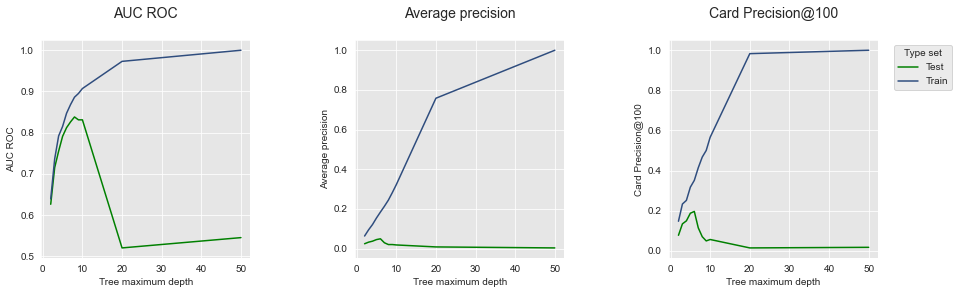

In [8]:
get_performances_plots(performances_df, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Train'],expe_type_color_list=['#008000','#2F4D7E'])

Observamos que los resultados son cualitativamente muy similares a [los obtenidos en datos simulados](Training_Vs_Test_Performances). El fenómeno de sobreajuste está claramente presente: A medida que aumenta la profundidad del árbol, también lo hace el rendimiento para todas las métricas (líneas azules), alcanzando rendimientos óptimos para una profundidad de árbol de 50. El rendimiento de prueba sin embargo alcanza su punto máximo para una profundidad de árbol entre 5 y 10, y luego disminuye para valores más altos del parámetro. 

Gracias a la reproducibilidad de los experimentos, notamos que los rendimientos obtenidos para una profundidad de árbol de 2 y 50 coinciden con los reportados en el [Capítulo 3](Chapter3_BaselineWL). 

## Rendimientos de modelos por clase de modelo

Exploremos más extensamente cómo la selección de modelos mejora los rendimientos usando validación prequencial en datos del mundo real. Reportamos a continuación los resultados para las cuatro clases de modelos, siguiendo la misma configuración experimental que en la [sección anterior](Model_Selection). Los resultados están disponibles en el archivo Pickle `performances_model_selection_real_world_data.pkl`. Carguemos primero el archivo.

In [14]:
filehandler = open('images/performances_model_selection_real_world_data.pkl', 'rb') 
(performances_df_dictionary, execution_times) = pickle.load(filehandler)

Los resultados están en el mismo formato que en la [sección anterior](Model_Selection). Los rendimientos se resumen como un diccionario en `performances_df_dictionary`, donde las claves corresponden a modelos.


In [102]:
performances_df_dictionary.keys()

dict_keys(['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression'])

Los tiempos de ejecución para cada modelo se almacenan en la lista `execution_times`.

In [103]:
execution_times

[1617.0470759868622,
 694.7196891307831,
 3615.5994658470154,
 8788.51293516159,
 5527.099639177322]

(Model_Selection_RWD_Decision_Trees)=
### Árboles de decisión
 
Los rendimientos de validación y prueba como una función de la profundidad del árbol se reportan a continuación, junto con el resumen de parámetros y rendimientos óptimos.

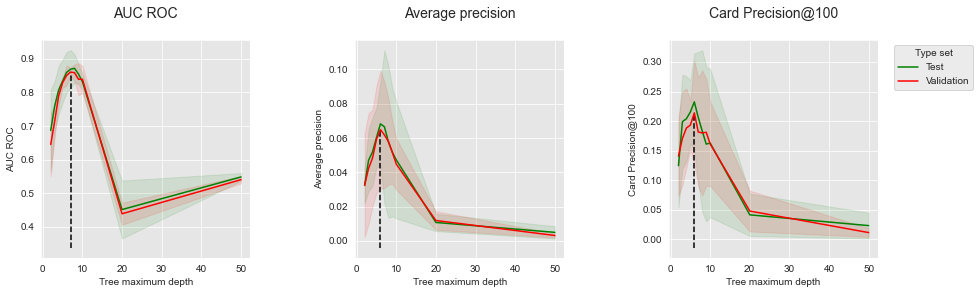

In [13]:
performances_df_dt=performances_df_dictionary['Decision Tree']
summary_performances_dt=get_summary_performances(performances_df_dt, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_dt, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       summary_performances=summary_performances_dt)

In [12]:
summary_performances_dt

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,7,6,6
Validation performance,0.861+/-0.01,0.065+/-0.02,0.214+/-0.04
Test performance,0.869+/-0.03,0.068+/-0.01,0.232+/-0.04
Optimal parameter(s),8,6,6
Optimal test performance,0.872+/-0.02,0.068+/-0.01,0.232+/-0.04


Similar a los resultados del conjunto de datos simulado, los rendimientos de validación proporcionan buenas estimaciones de los rendimientos de prueba. La profundidad óptima del árbol, entre 6 y 9 dependiendo de la métrica de rendimiento, es más alta que con los datos simulados. Esto se puede explicar por las relaciones más complejas entre características de entrada y etiqueta de fraude en el conjunto de datos del mundo real. 

(Model_Selection_RWD_Logistic_Regression)=
### Regresión logística
 
Los rendimientos de validación y prueba como una función del valor de regularización se reportan a continuación, junto con el resumen de parámetros y rendimientos óptimos.

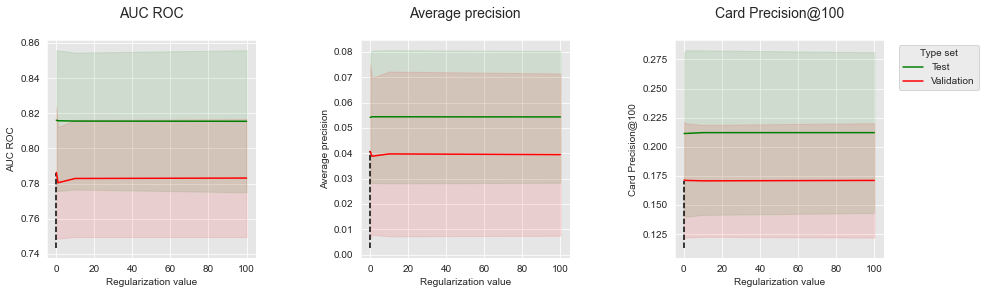

In [107]:
performances_df_lr=performances_df_dictionary['Logistic Regression']
summary_performances_lr=get_summary_performances(performances_df_lr, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_lr, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name='Regularization value',
                       summary_performances=summary_performances_lr)

In [105]:
summary_performances_lr

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,0.1,0.1,0.1
Validation performance,0.786+/-0.02,0.041+/-0.02,0.171+/-0.03
Test performance,0.816+/-0.02,0.054+/-0.01,0.211+/-0.03
Optimal parameter(s),0.1,1.0,10.0
Optimal test performance,0.816+/-0.02,0.054+/-0.01,0.212+/-0.04


Similar al [conjunto de datos simulado](Model_Selection_Logistic_Regression), el valor de regularización tiene poca influencia en los rendimientos. Los rendimientos son estables en todo el rango de valores de regularización probados.

(Model_Selection_RWD_RF)=
### Random forest

Two different parameters are assessed for random forests: The tree depth (`max_depth` parameter), taking values in the set [5,10,20,50], and the number of trees (`n_estimators` parameter), taking values in the set [25,50,100]. Overall, the optimal parameters are a combination of 100 trees with a maximum depth of 10.


In [113]:
performances_df_rf=performances_df_dictionary['Random Forest']
summary_performances_rf=get_summary_performances(performances_df_rf, parameter_column_name="Parameters summary")
summary_performances_rf

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,25/10,100/10,100/10
Validation performance,0.917+/-0.0,0.093+/-0.02,0.258+/-0.03
Test performance,0.912+/-0.02,0.08+/-0.03,0.227+/-0.05
Optimal parameter(s),100/10,100/10,50/5
Optimal test performance,0.912+/-0.02,0.08+/-0.03,0.227+/-0.04


Para una mejor visualización, seguimos el mismo enfoque que con el [conjunto de datos simulado](Model_Selection_Random_Forest). Reportemos primero los rendimientos como una función de la profundidad del árbol, para un número fijo de 100 árboles.


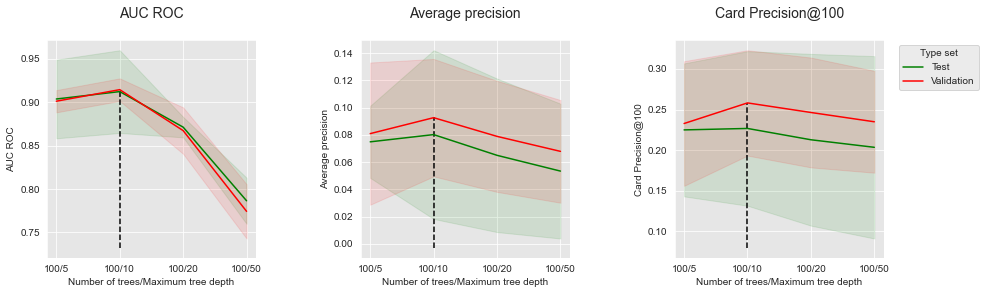

In [111]:


performances_df_rf_fixed_number_of_trees=performances_df_rf[performances_df_rf["Parameters summary"].str.startswith("100")]

summary_performances_fixed_number_of_trees=get_summary_performances(performances_df_rf_fixed_number_of_trees, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_rf_fixed_number_of_trees, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_number_of_trees)

Similar al [conjunto de datos simulado](Model_Selection_Random_Forest), los rendimientos primero aumentan con la profundidad del árbol, antes de alcanzar un óptimo y disminuir. La profundidad óptima del árbol se encuentra alrededor de 10.

Reportemos entonces los rendimientos como una función del número de árboles, para una profundidad fija de 10.

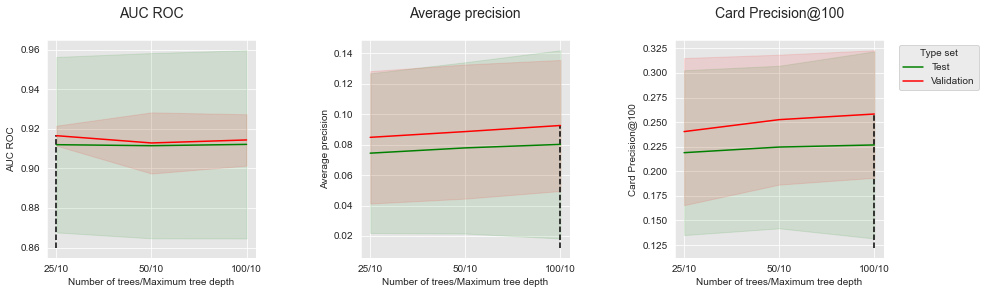

In [114]:
performances_df_rf_fixed_max_tree_depth=performances_df_rf[performances_df_rf["Parameters summary"].str.endswith("10")]

summary_performances_fixed_max_tree_depth=get_summary_performances(performances_df_rf_fixed_max_tree_depth, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_rf_fixed_max_tree_depth, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_max_tree_depth)

Increasing the number of trees allows to slighlty increase the Average Precicision and the CP@100. It however has little influence on the AUC ROC, for which 25 trees already provide optimal performances.  

(Model_Selection_RWD_XGBoost)=
### XGBoost

Three different parameters are assessed for boosting: The tree depth (`max_depth` parameter) taking values in the set [3,6,9], the number of trees (`n_estimators` parameter) taking values in the set [25,50,100] and the learning rate (`learning_rate` parameter) taking values in the set [0.1, 0.3]. The optimal parameters are a combination of 100 trees with a maximum depth of 6, and a learning rate of 0.1, except for the CP@100 where 50 trees provide the best performance. 


In [140]:
performances_df_xgboost=performances_df_dictionary['XGBoost']
summary_performances_xgboost=get_summary_performances(performances_df_xgboost, parameter_column_name="Parameters summary")
summary_performances_xgboost

,AUC ROC,Average precision,Card Precision@100
Best estimated parameters,100/0.1/6,100/0.1/6,100/0.1/6
Validation performance,0.924+/-0.01,0.102+/-0.02,0.261+/-0.02
Test performance,0.928+/-0.01,0.095+/-0.03,0.235+/-0.07
Optimal parameter(s),100/0.1/6,100/0.1/6,50/0.1/6
Optimal test performance,0.928+/-0.01,0.095+/-0.03,0.249+/-0.04


Para una mejor visualización, seguimos el mismo enfoque que con el [conjunto de datos simulado](Model_Selection_XGBoost). Reportemos primero los rendimientos como una función de la profundidad del árbol, para un número fijo de 100 árboles y una tasa de aprendizaje de 0.1.

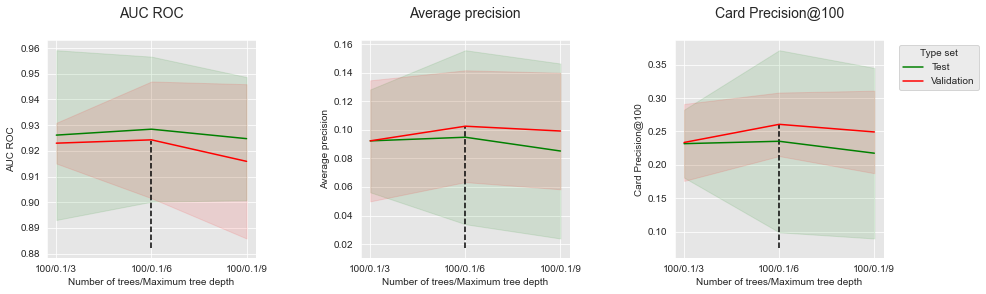

In [141]:
performances_df_xgboost_fixed_number_of_trees=performances_df_xgboost[performances_df_xgboost["Parameters summary"].str.startswith("100/0.1")]

summary_performances_fixed_number_of_trees=get_summary_performances(performances_df_xgboost_fixed_number_of_trees, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_xgboost_fixed_number_of_trees, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_number_of_trees)

Similar al [conjunto de datos simulado](Model_Selection_XGBoost), los rendimientos primero aumentan con la profundidad del árbol, antes de alcanzar un óptimo y disminuir. La profundidad óptima del árbol se encuentra alrededor de 6.

Reportemos entonces los rendimientos como una función del número de árboles, para una profundidad fija de 6 y una tasa de aprendizaje de 0.1.

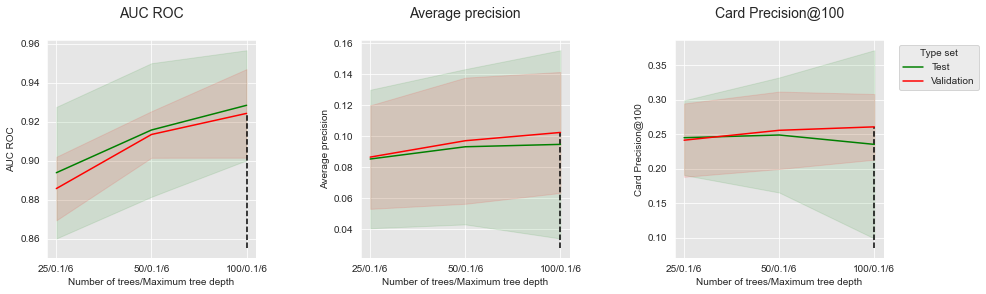

In [142]:
performances_df_xgboost_fixed_max_tree_depth=performances_df_xgboost[performances_df_xgboost["Parameters summary"].str.endswith("0.1/6")]

summary_performances_fixed_max_tree_depth=get_summary_performances(performances_df_xgboost_fixed_max_tree_depth, parameter_column_name="Parameters summary")

get_performances_plots(performances_df_xgboost_fixed_max_tree_depth, 
                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                       expe_type_list=['Test','Validation'], expe_type_color_list=['#008000','#FF0000'],
                       parameter_name="Number of trees/Maximum tree depth",
                       summary_performances=summary_performances_fixed_max_tree_depth)

Increasing the number of trees allows to increase the AUC ROC and the Average Precicision. We however note that for the CP@100, a decrease of performance occurs after 50 trees for the test set.  

(Model_Selection_RWD_Comparison)=
## Comparación de rendimientos de modelos: Resumen

Comparemos finalmente los rendimientos de las diferentes clases de modelos. Similar al [conjunto de datos simulado](Model_Selection_Comparison_Performances), graficamos los rendimientos para las cuatro clases de modelos y para cada métrica de rendimiento como gráficos de barras usando la función `get_model_selection_performances_plots`.


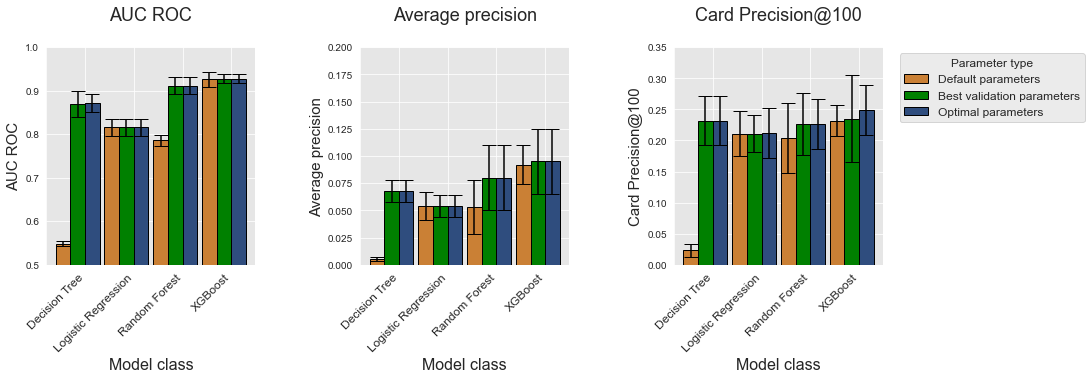

In [143]:
get_model_selection_performances_plots(performances_df_dictionary, 
                                       performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                       ylim_list=[[0.5,1],[0,0.2],[0,0.35]],
                                       model_classes=['Decision Tree', 
                                                      'Logistic Regression', 
                                                      'Random Forest', 
                                                      'XGBoost'])
    

Como para los datos simulados, XGBoost es la clase de modelo que proporciona los mejores rendimientos para las tres métricas (Parámetros óptimos, representados con barras azules). Sin embargo, vale la pena notar que para CP@100, los parámetros óptimos de XGBoost en realidad no se encuentran mediante el procedimiento de selección de modelos, resultando en rendimientos más bajos. Los rendimientos reales en términos de CP@100 son ligeramente mejores que los bosques aleatorios, y similares a los árboles de decisión.

Este es un resultado que vale la pena considerar: Gracias a la selección de modelos, el modelo de árbol de decisión es en realidad tan performante como XGBoost, y más performante que los bosques aleatorios en términos de CP@100. Los tiempos de ejecución para árboles de decisión son sin embargo mucho más bajos que los de bosques aleatorios y XGBoost, como se reporta a continuación.



In [144]:
# %%capture
# 
# fig_model_selection_execution_times_for_each_model_class, ax = plt.subplots(1, 1, figsize=(5,4))
# 
# model_classes=['Decision Tree','Logistic Regression','Random Forest','XGBoost']
#     
# # width of the bars
# barWidth = 0.3
# # The x position of bars
# r1 = np.arange(len(model_classes))
#     
# # Create execution times bars
# ax.bar(r1, execution_times[0:4], 
#         width = barWidth, color = 'black', edgecolor = 'black', 
#         capsize=7)
# 
# ax.set_xticks(r1+barWidth/2)
# ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
# ax.set_title('Model selection execution times \n for different model classes', fontsize=18)
# ax.set_xlabel("Model class", fontsize=16)
# ax.set_ylabel("Execution times (s)", fontsize=15)


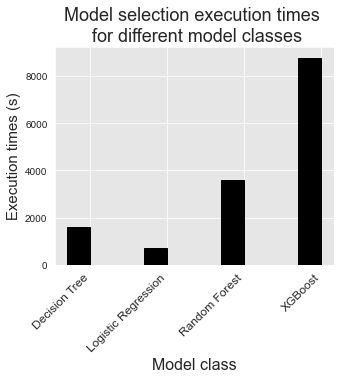

In [145]:
fig_model_selection_execution_times_for_each_model_class

Debe tenerse en cuenta que los experimentos se ejecutaron en un servidor de 40 núcleos, con computación paralela habilitada para bosques aleatorios y XGBoost. Por lo tanto, el procedimiento de selección de modelos para árboles de decisión es de hecho uno a dos órdenes de magnitud más rápido que para bosques aleatorios y XGBoost.

Como observación final, notamos que los modelos de regresión logística fueron los más rápidos de entrenar, pero también proporcionaron los peores rendimientos para todas las métricas. 